In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import tqdm
import re
import os
import glob
import spectres
from astropy import units as u

%matplotlib inline

In [3]:
SPS_HOME = os.path.abspath(os.path.join(os.getcwd(), '..'))
# SPS_HOME = os.getenv('SPS_HOME')
# SPS_HOME = SPS_HOME.replace('fsps', 'fsps_dev')  # -> I call my development folder for fsps 'fsps_dev' to keep it separate from my working fsps installation

logz_all = np.array([-1.3, -0.7, -0.4, 0.0, 0.3])
zstr = ['m13', 'm07', 'm04', 'p00', 'p03']
zi = 0
print(SPS_HOME)

print(zstr[zi], logz_all[zi])

/Users/mreefe/Dropbox/Astrophysics/fsps_dev
m13 -1.3


In [4]:
# Read in the Leitherer WM-Basic models with a custom parsing function because they're in a weird format
wave_file = '/Users/mreefe/Dropbox/Astrophysics/stellar_templates/galaxy/lejeune/ifa_wave.txt'
wave = np.loadtxt(wave_file)
wave = wave.ravel()

logts = np.zeros(0, dtype=float)
loggs = np.zeros(0, dtype=float)
logzs = np.zeros(0, dtype=float)
line_specs = np.zeros((len(wave), 0), dtype=float)
cont_specs = np.zeros((len(wave), 0), dtype=float)

line_file = open(f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/galaxy/lejeune/ifa_line_{zstr[zi]}.txt', 'r')
cont_file = open(f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/galaxy/lejeune/ifa_cont_{zstr[zi]}.txt', 'r')
teffi = []
loggi = []
llines = line_file.readlines()
lconts = cont_file.readlines()

speci = np.zeros(0, dtype=float)
cspeci = np.zeros(0, dtype=float)

for i,line in enumerate(llines):
    row = [float(li) for li in line.strip().replace('-', ' -').split(' ') if li != '']
    crow = [float(li) for li in lconts[i].strip().replace('-', ' -').split(' ') if li != '']
    
    if len(row) == 2:
        # the last spectrum is done being read; append it to the array
        # and reset the 'speci' variable
        if len(speci) > 0:
            line_specs = np.concatenate((line_specs, speci.reshape((len(speci), 1))), axis=1)
            cont_specs = np.concatenate((cont_specs, cspeci.reshape((len(cspeci), 1))), axis=1)
            speci = np.zeros(0, dtype=float)
            cspeci = np.zeros(0, dtype=float)
        # append the new Teff and logg
        teffi.append(row[0])
        loggi.append(row[1])
        continue
    # append to the current spectrum
    speci = np.append(speci, row)
    cspeci = np.append(cspeci, crow)
    # if this is the last line, make sure to append the final spectrum
    if i == (len(llines)-1):
        line_specs = np.concatenate((line_specs, speci.reshape((len(speci), 1))), axis=1)
        cont_specs = np.concatenate((cont_specs, cspeci.reshape((len(cspeci), 1))), axis=1)

line_file.close()
cont_file.close()

teffi = np.array(teffi)
loggi = np.array(loggi)
logzi = np.ones(len(teffi))*logz_all[zi]

logts = np.append(logts, np.log10(teffi))
loggs = np.append(loggs, loggi)
logzs = np.append(logzs, logzi) 

# filter out stars with Teff < 25,000
mask = teffi >= 25000
logts = logts[mask]
loggs = loggs[mask]
logzs = logzs[mask]
line_specs = line_specs[:,mask]
cont_specs = cont_specs[:,mask]

print(logts.shape)
print(loggs.shape)
print(logzs.shape)
print(line_specs.shape)
print(cont_specs.shape)

(75,)
(75,)
(75,)
(4200, 75)
(4200, 75)


/var/folders/_d/811k0zw90qn5rglh8sn17ryr0000gn/T/ipykernel_9174/4207889908.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


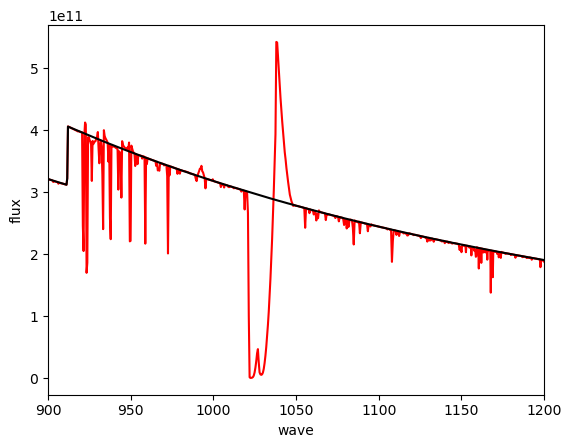

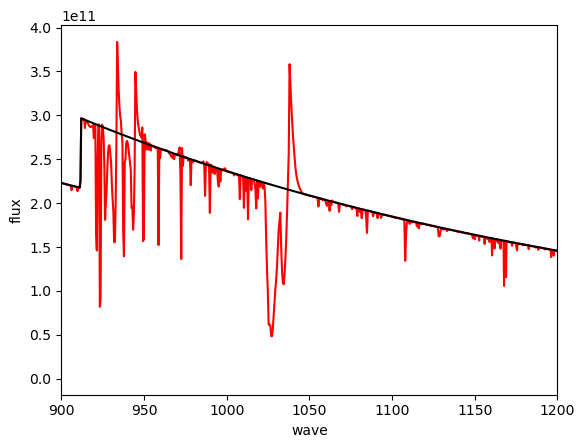

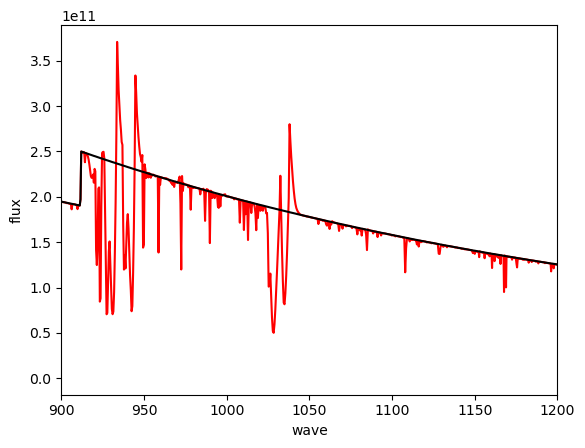

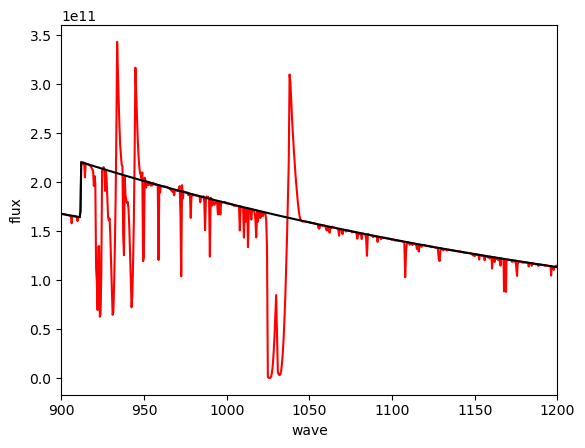

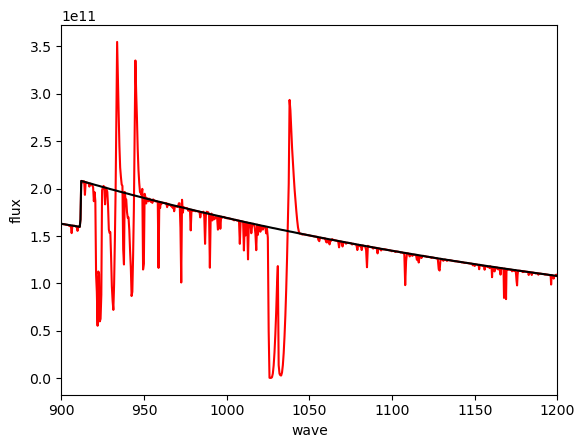

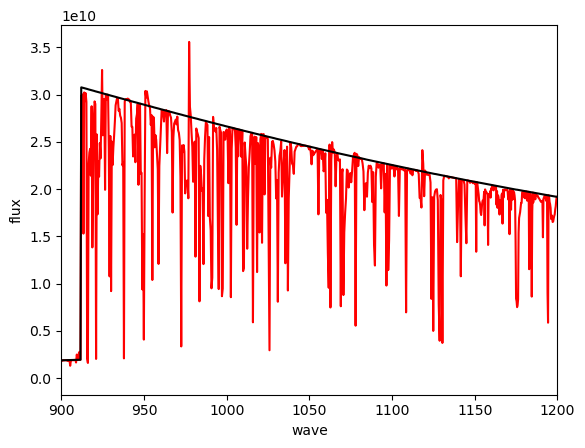

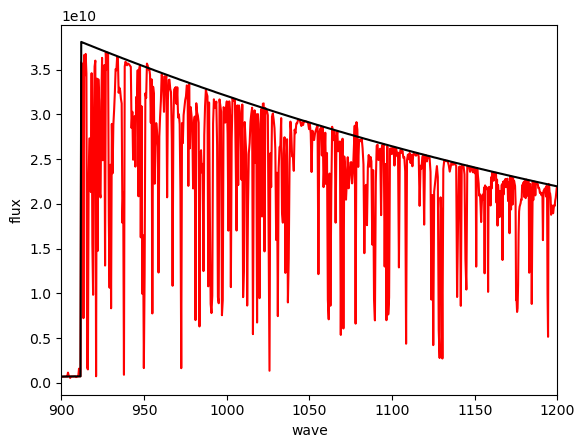

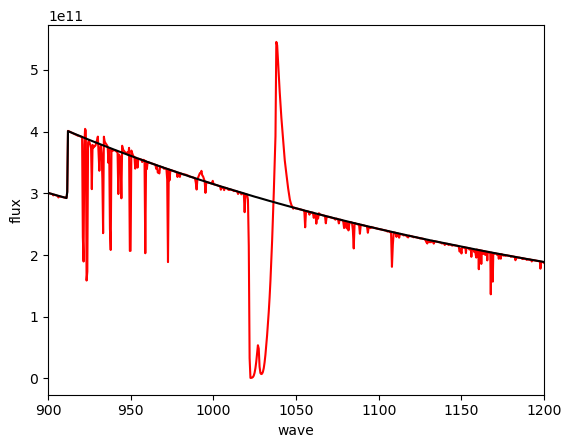

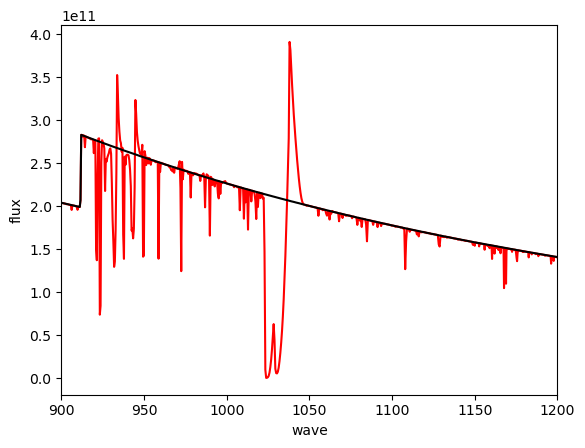

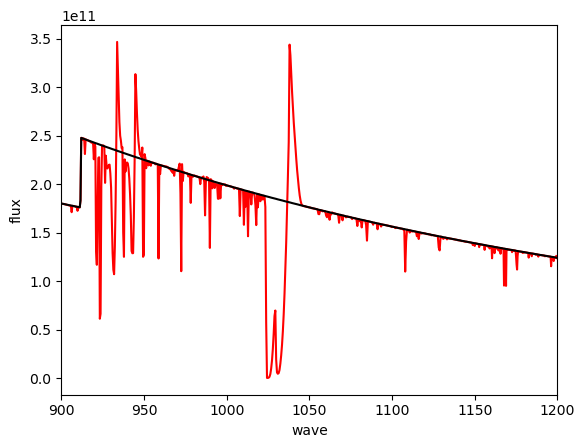

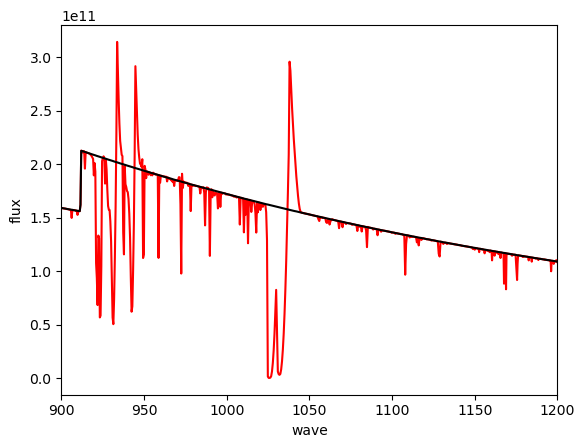

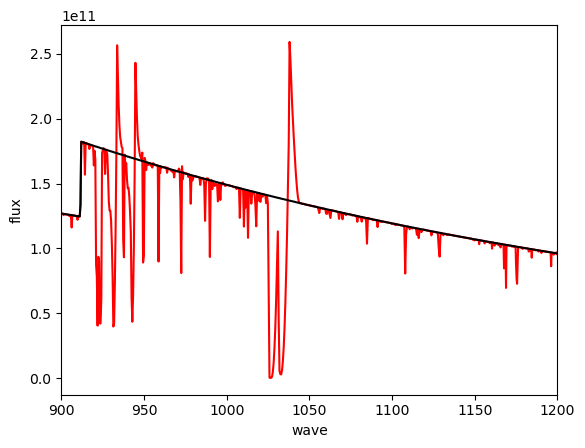

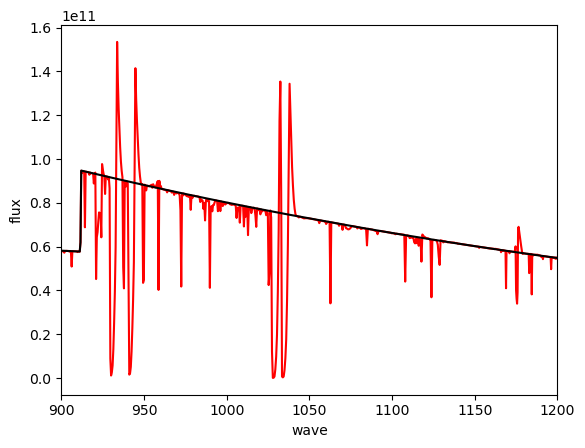

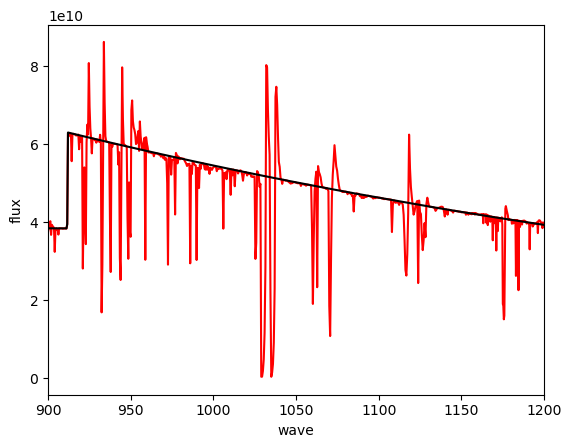

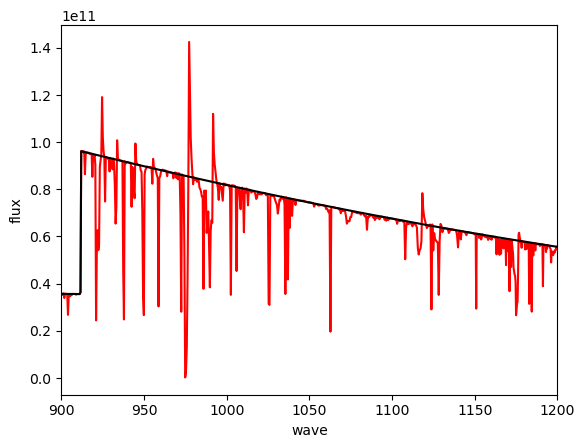

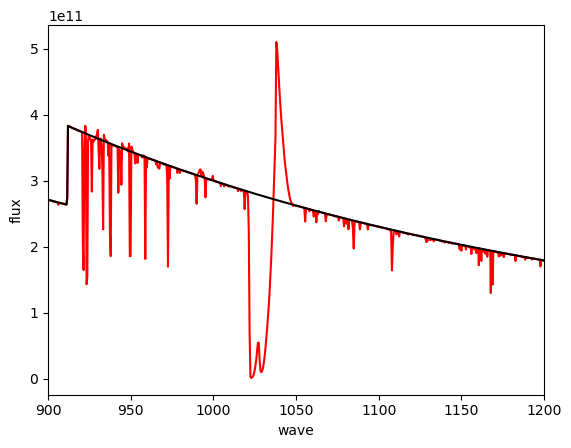

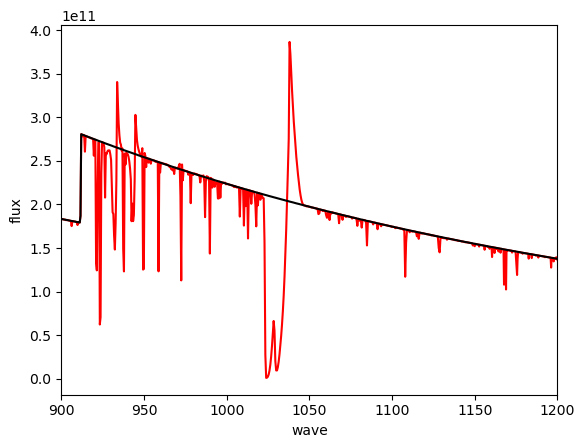

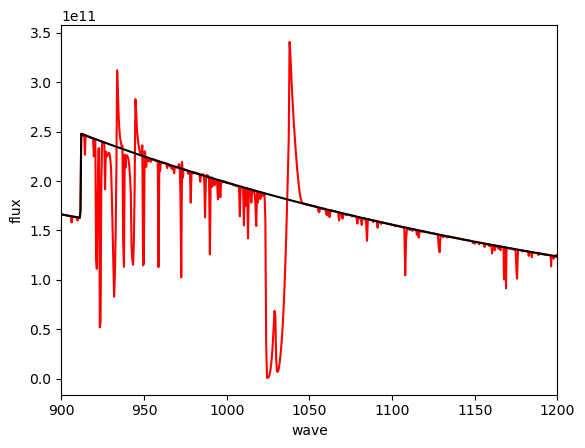

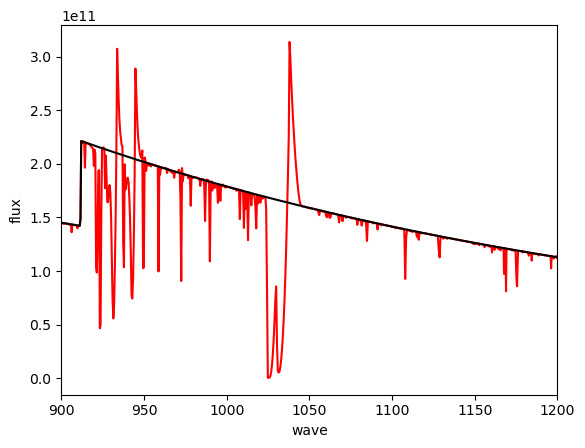

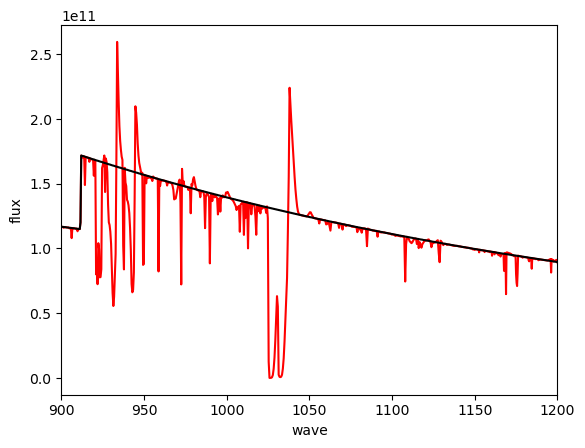

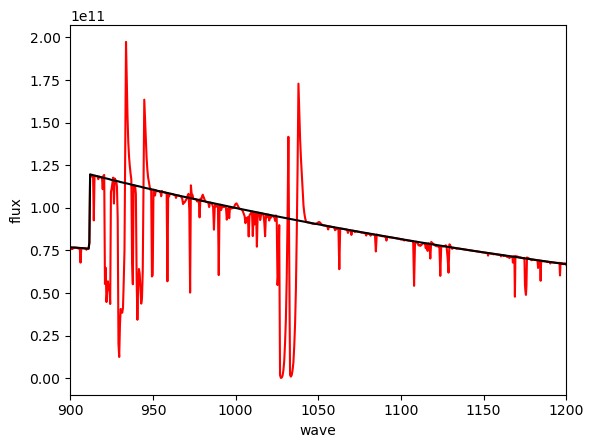

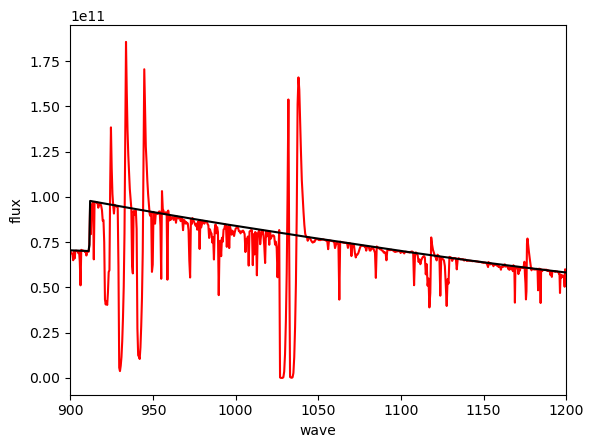

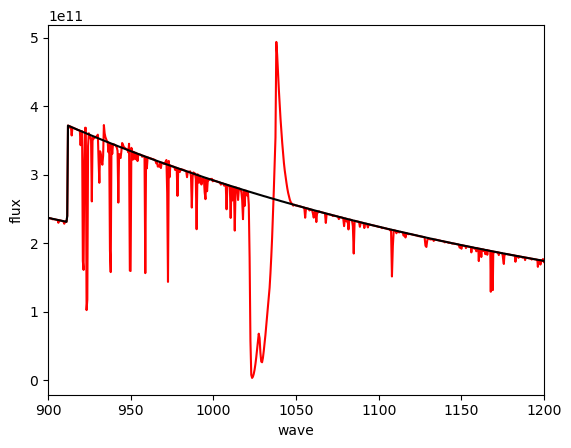

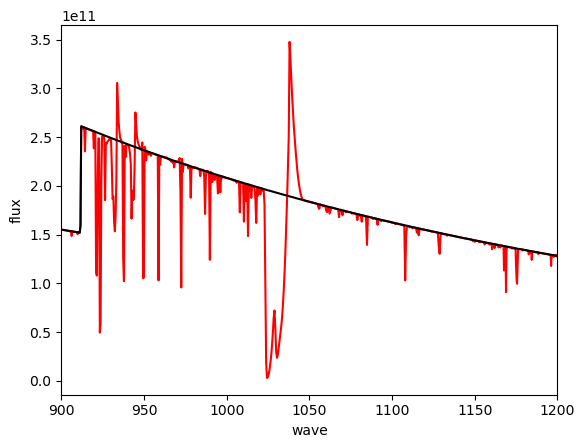

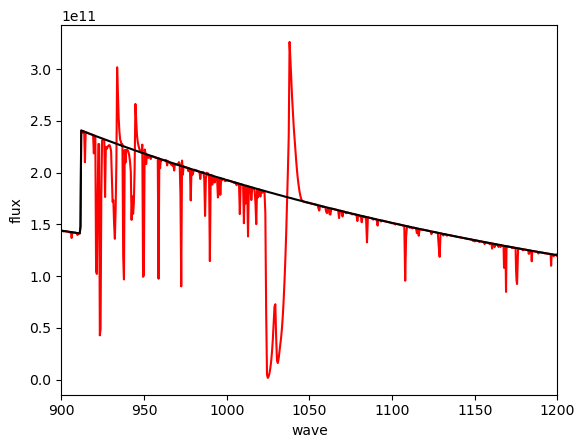

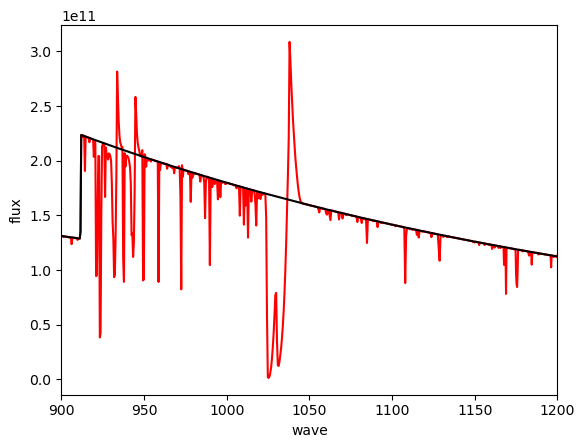

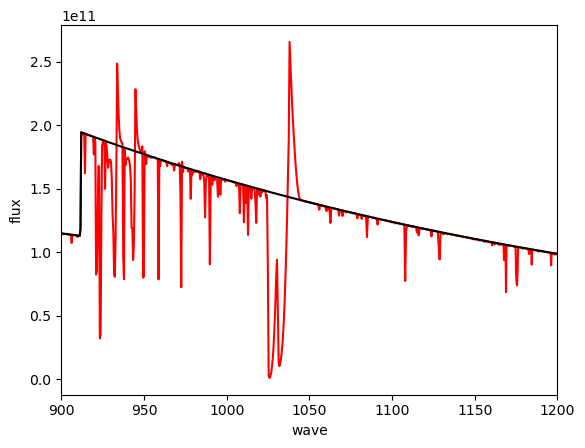

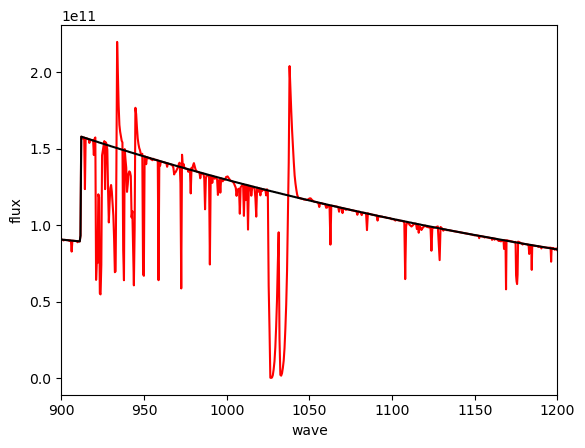

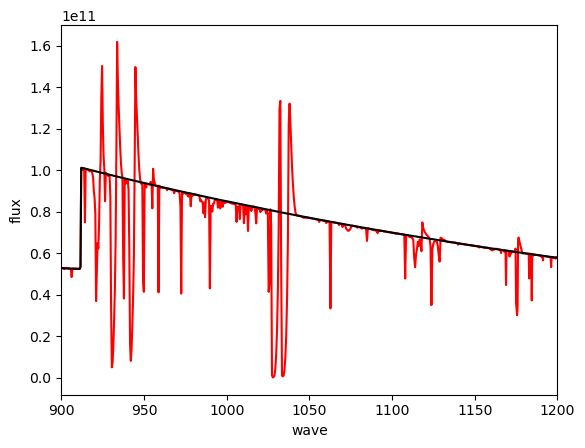

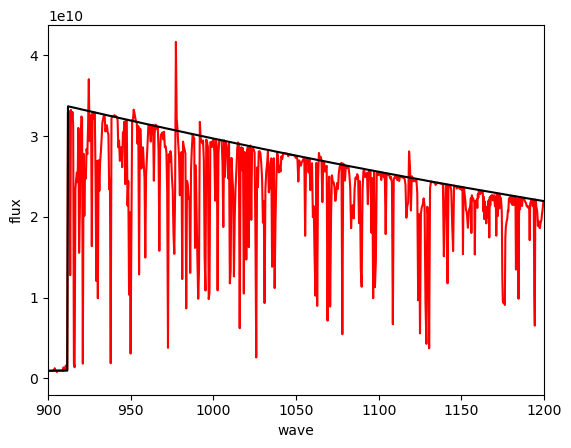

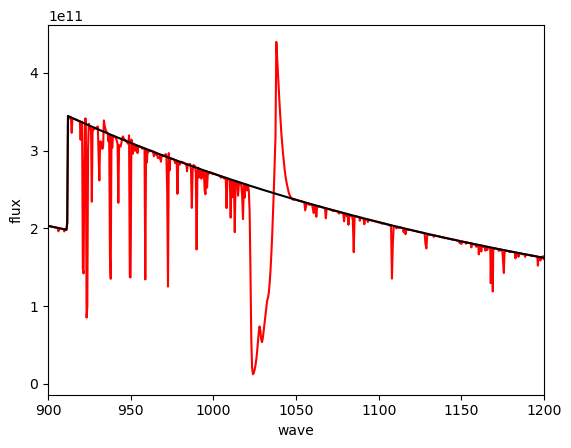

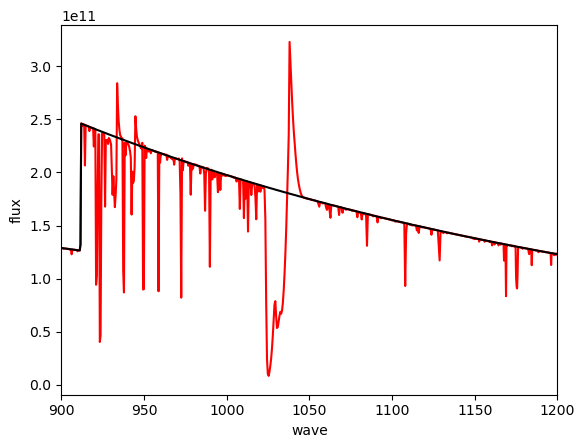

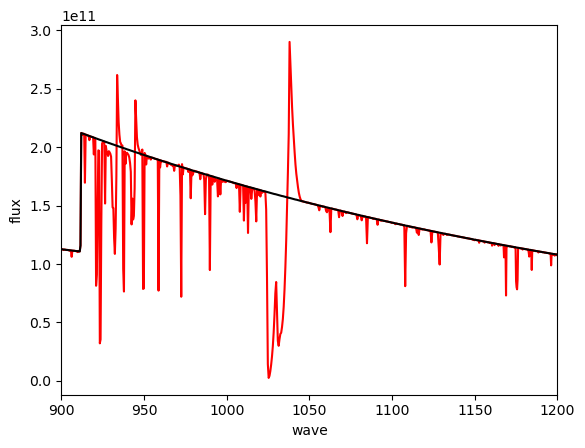

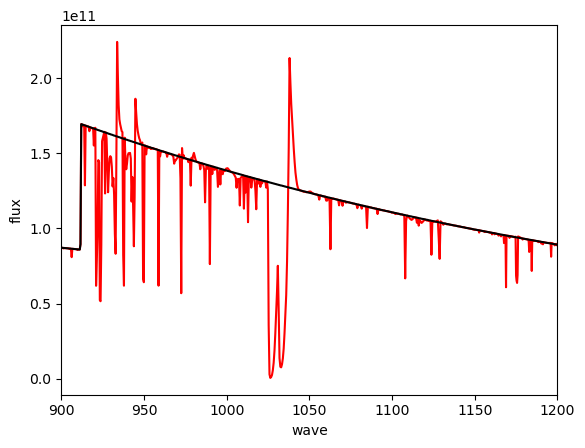

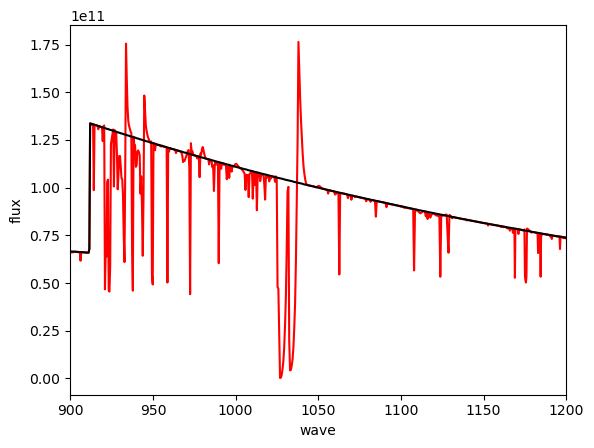

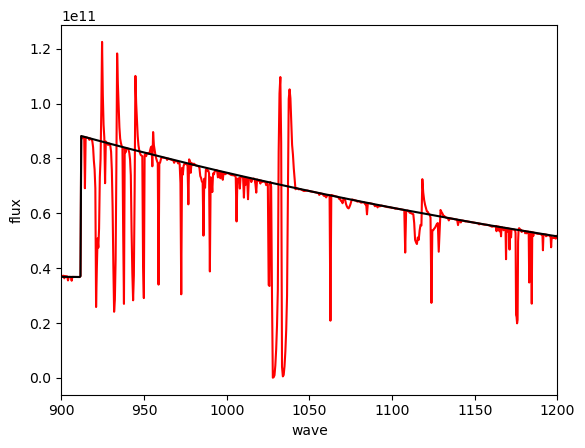

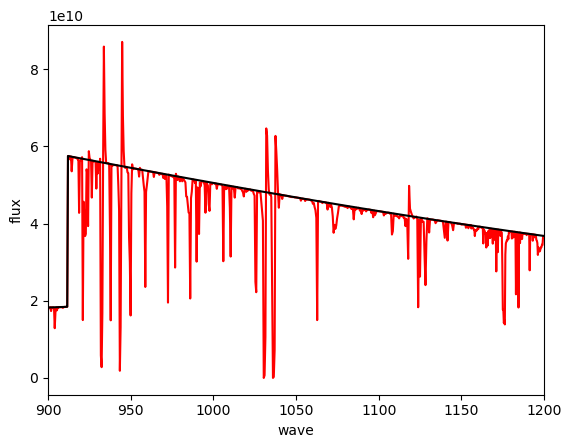

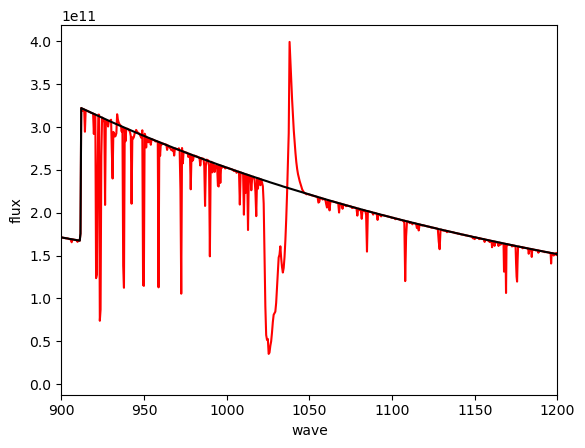

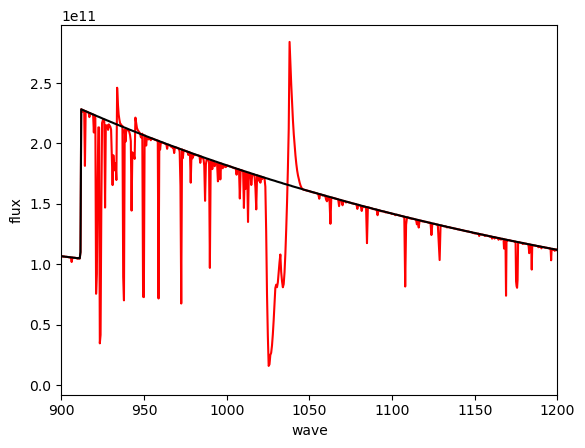

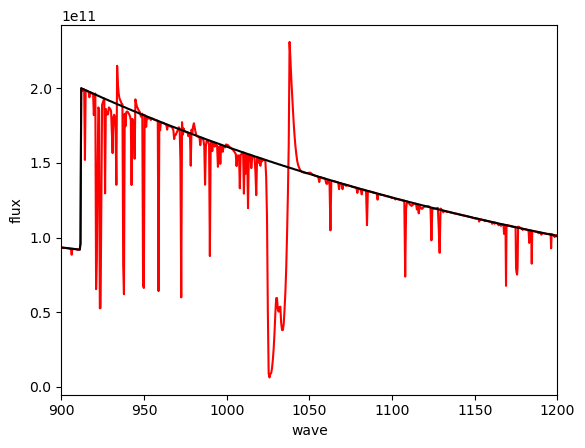

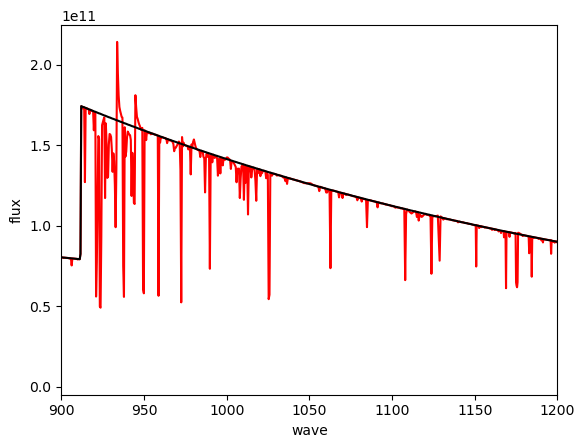

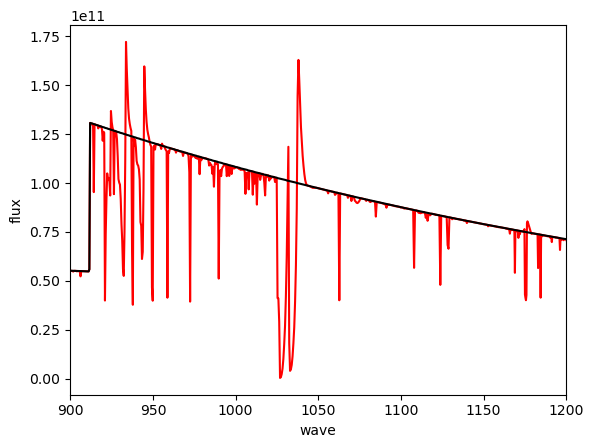

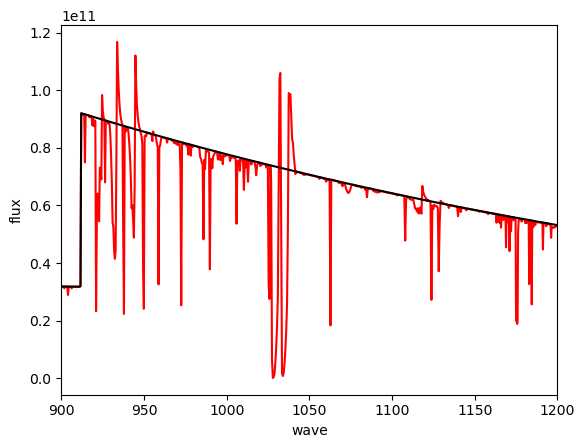

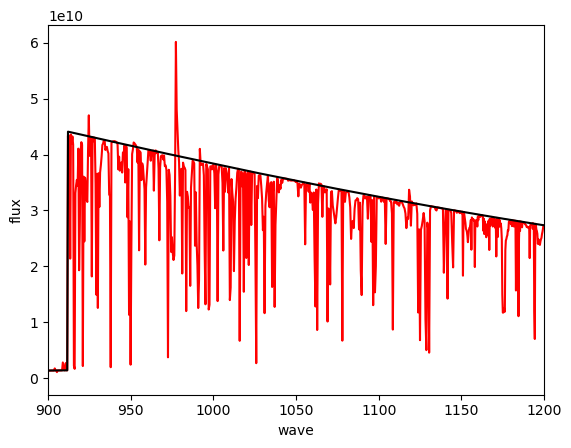

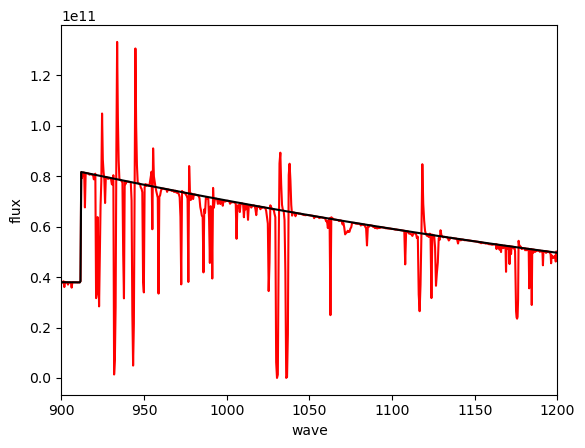

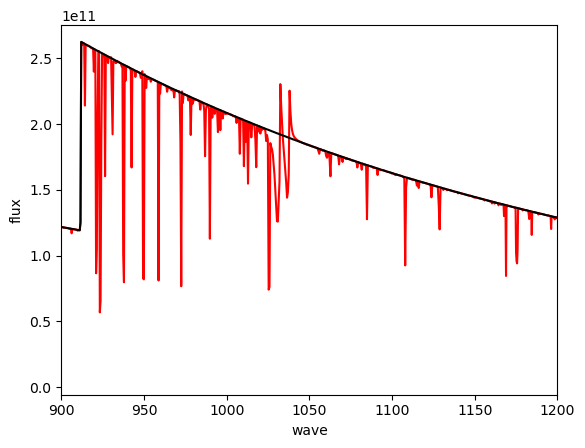

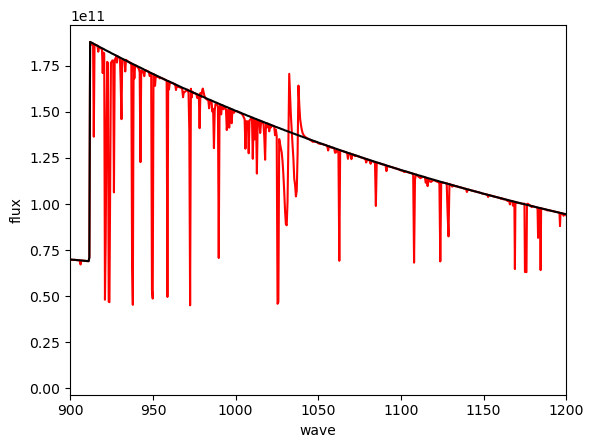

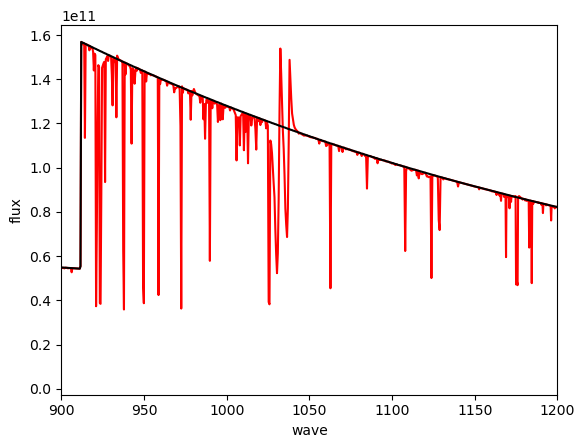

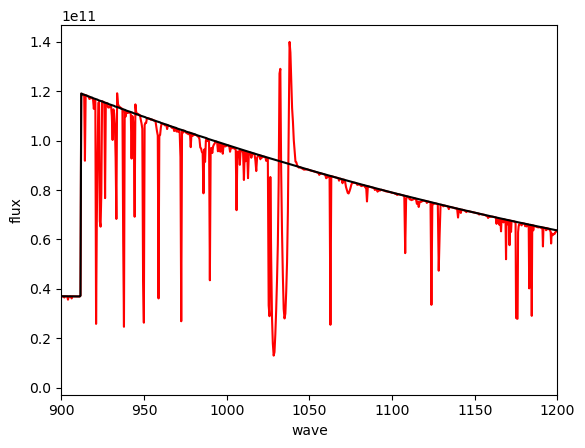

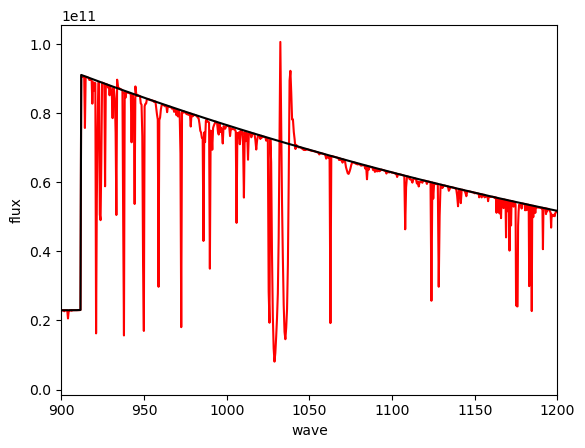

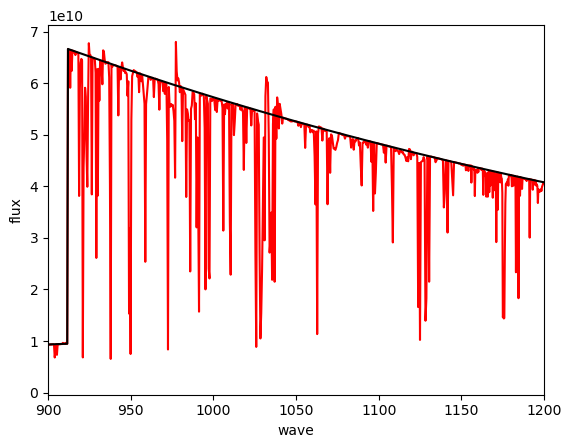

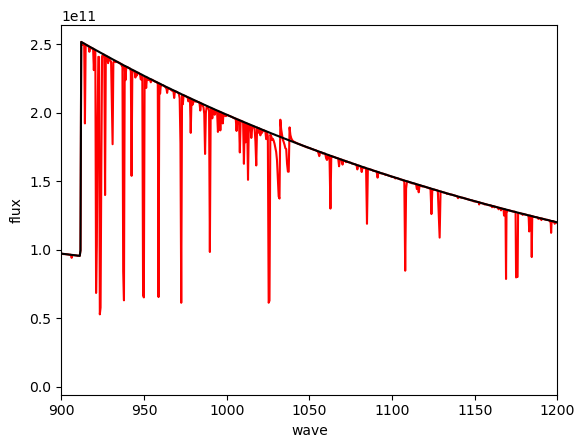

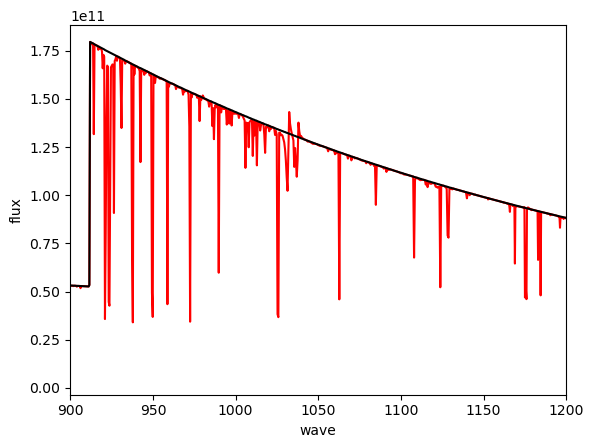

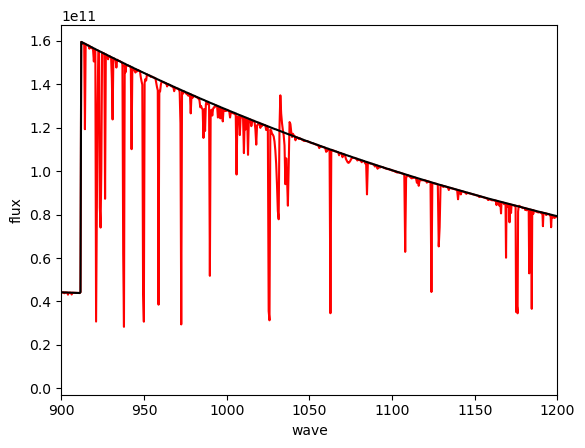

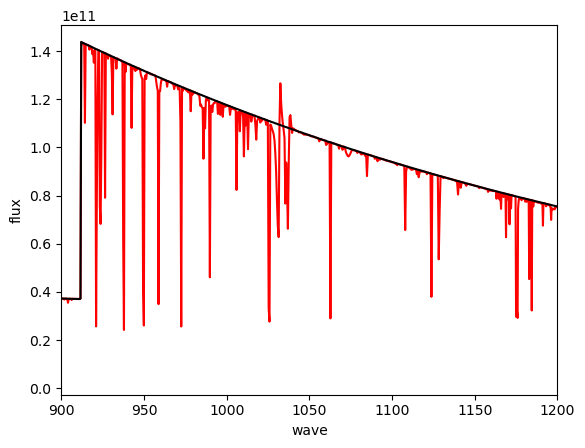

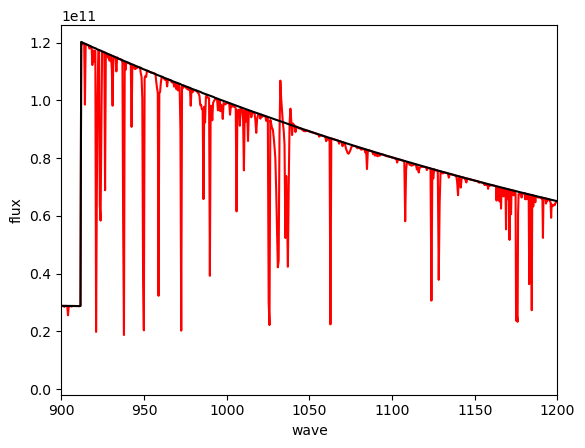

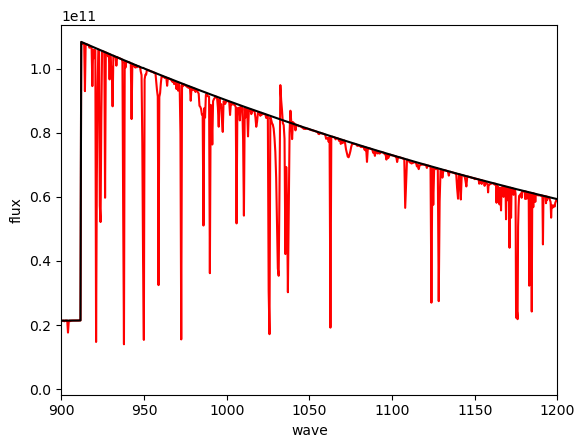

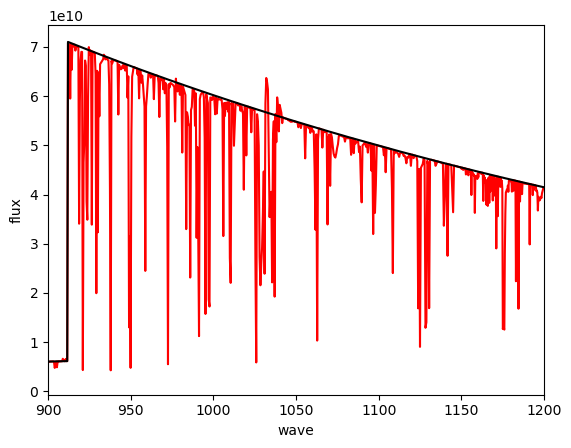

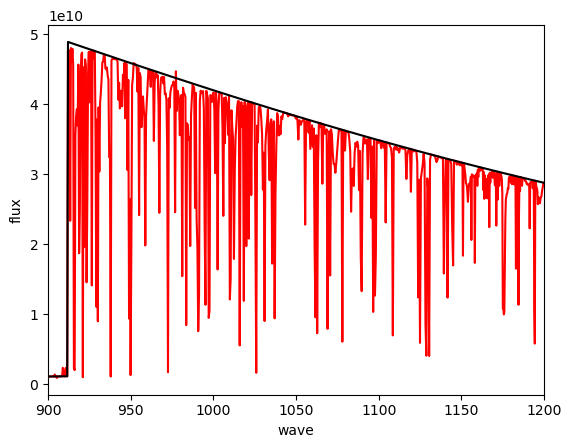

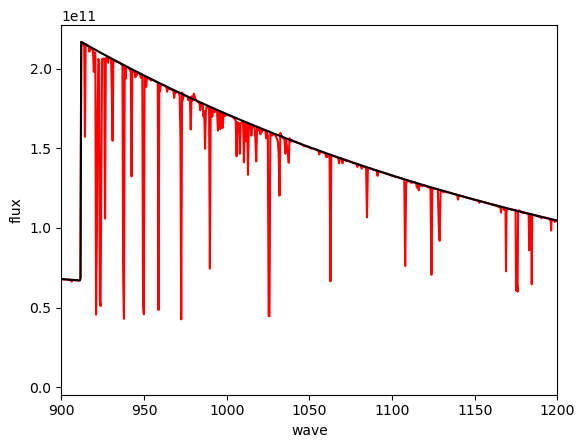

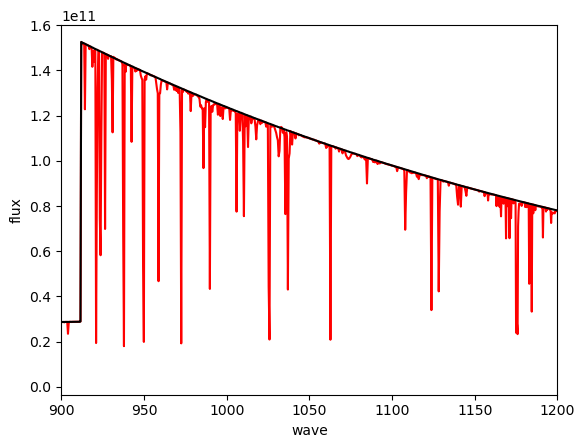

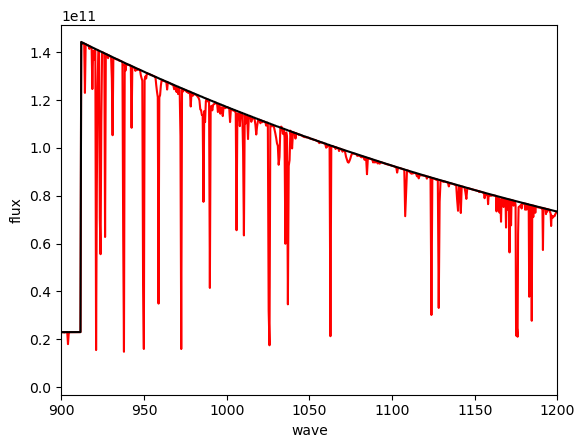

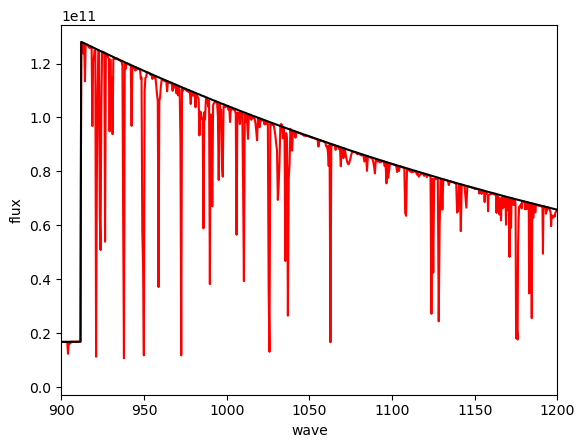

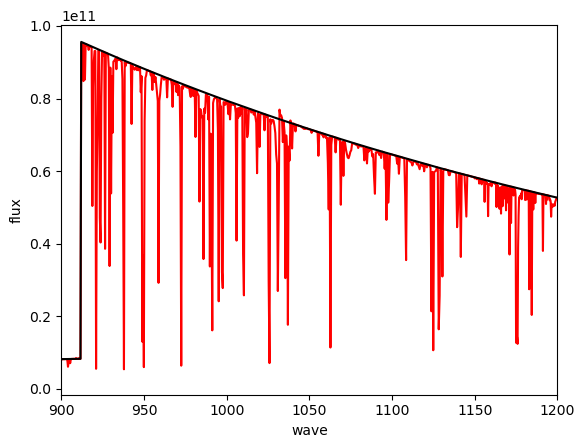

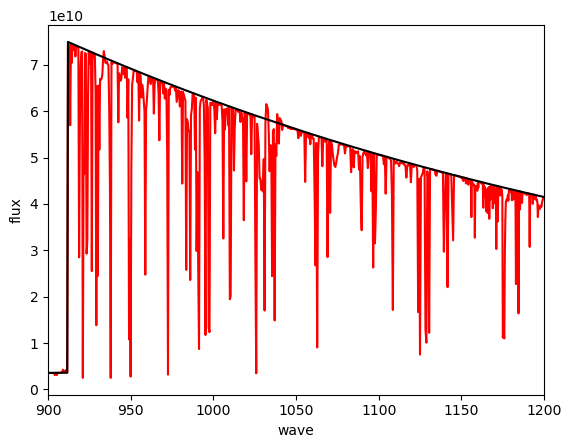

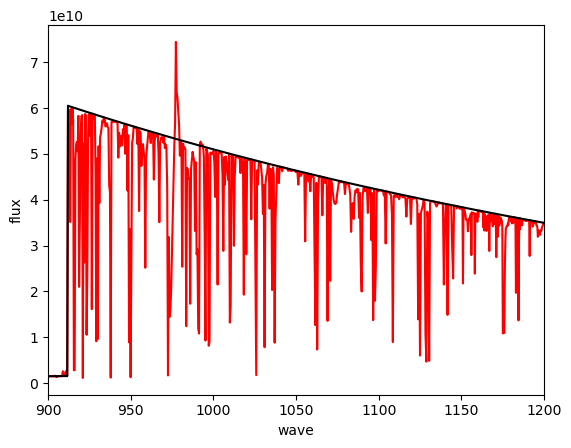

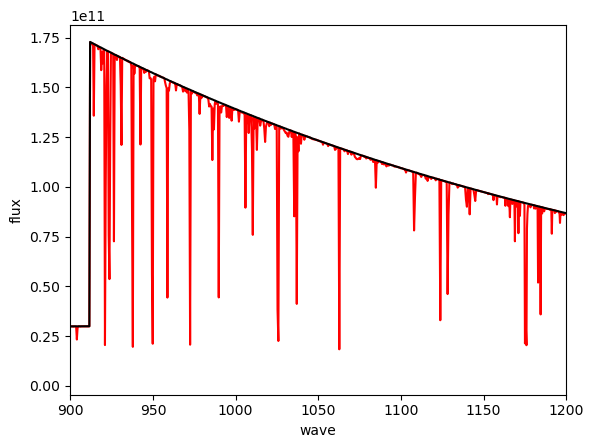

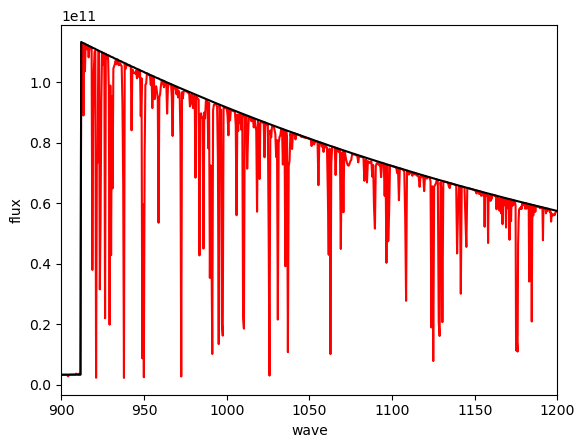

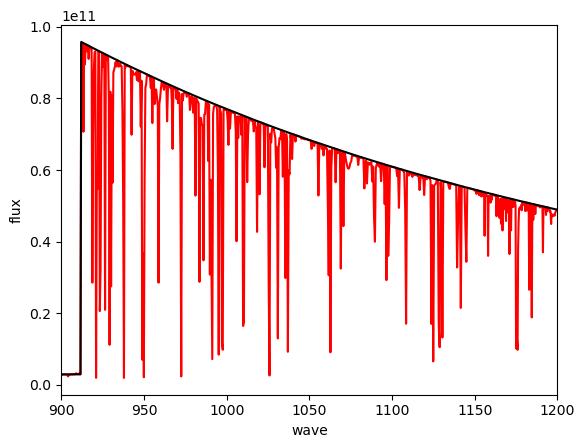

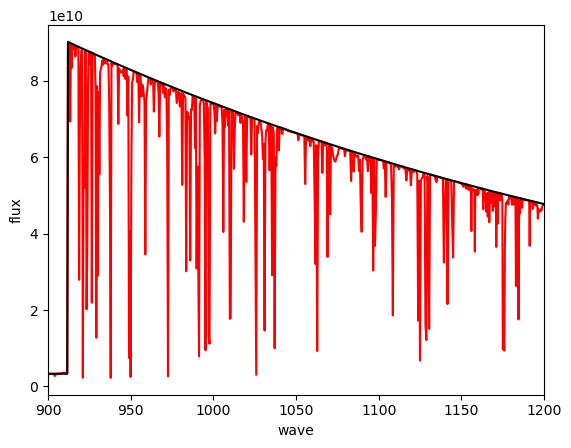

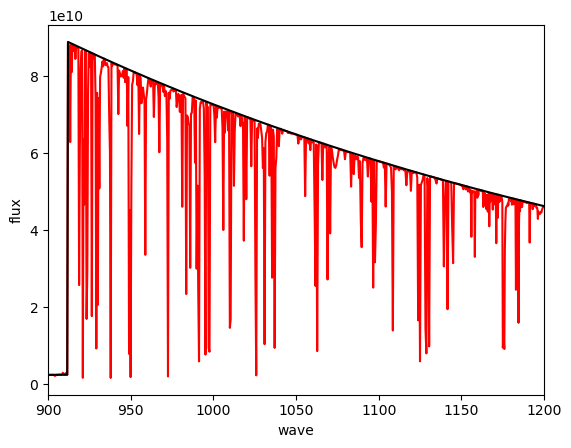

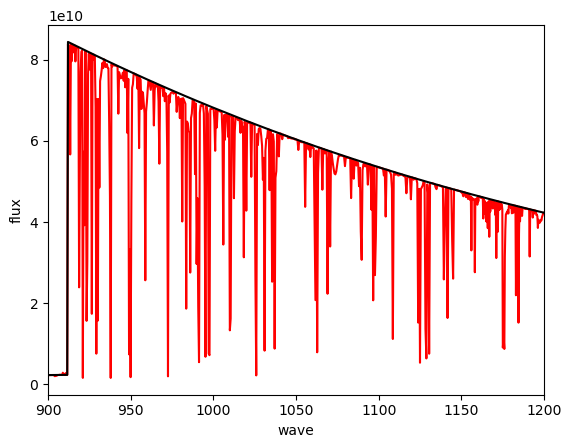

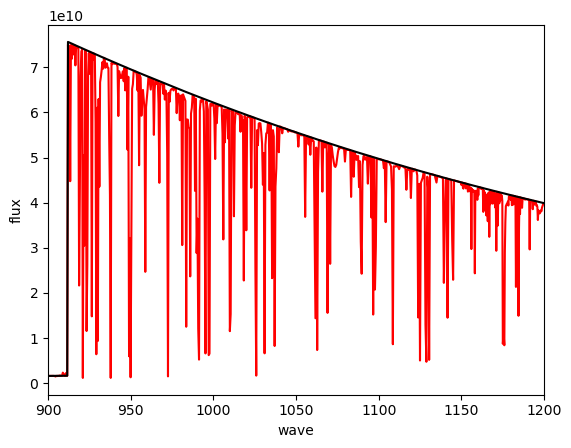

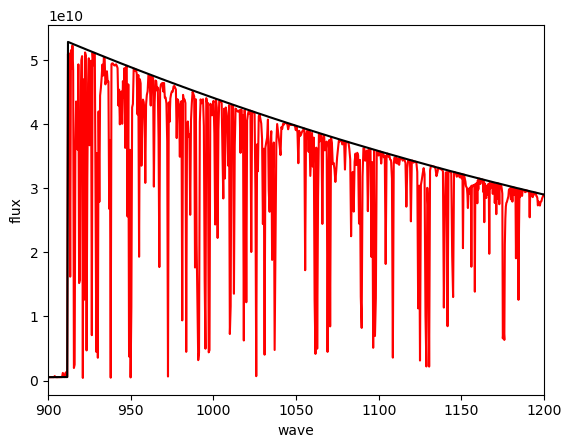

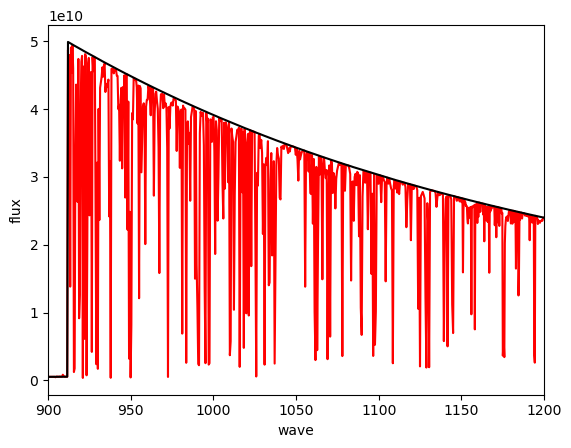

In [7]:
for i in range(line_specs.shape[1]):

    fig, ax = plt.subplots()
    ax.plot(wave, line_specs[:,i], 'r-')
    ax.plot(wave, cont_specs[:,i], 'k-')
    ax.set_xlabel('wave')
    ax.set_ylabel('flux')
    ax.set_xlim(900, 1200)

specs = line_specs

In [82]:
# Define the wavelength grid that we will resample onto
# -> even logarithmic spacing by ~5% of the current wavelength
w_1 = 90. * 1.05**np.arange(0, int(np.log(800/90)/np.log(1.05))) 
# -> finer sampling in the FUV;
w_2 = np.arange(800., 1800., 0.2)
w_3 = np.arange(1800., 9000., 20.)
# -> spacing by ~5% of the current wavelength
w_4 = 9000. * 1.05**np.arange(0, int(np.log(9.99e6/9000)/np.log(1.05))) 

wavelength = np.concatenate((w_1, w_2, w_3, w_4))
print('w_1 = ', len(w_1))
print('w_2 = ', len(w_2))
print('w_3 = ', len(w_3))
print('w_4 = ', len(w_4))
print('length = ', len(wavelength))
print(wavelength)

w_1 =  44
w_2 =  5000
w_3 =  360
w_4 =  143
length =  5547
[9.00000000e+01 9.45000000e+01 9.92250000e+01 ... 8.33190634e+06
 8.74850165e+06 9.18592674e+06]


In [83]:
# wavelength must be in angstroms!
def airtovac(wavelength):
    # see: https://www.astro.uu.se/valdwiki/Air-to-vacuum%20conversion
    s = 1e4 / wavelength
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    # do not alter wavelengths below 2000 angstroms 
    wh = np.where(wavelength < 2000.)[0]
    n[wh] = 1.0
    return wavelength * n

In [84]:
# Define the teff, logg, and logz arrays that cover the grid of Brown+1996 models

teff_1 = np.arange(10000, 13000, 500)
teff_2 = np.arange(13000, 20000, 1000)
teff_3 = np.arange(20000, 30000, 2000)
teff_4 = np.arange(30000, 50000, 2500)
teff_5 = np.arange(50000, 120000, 5000)
teff_6 = np.arange(120000, 200000, 20000)
teff_7 = np.arange(200000, 250000+25000, 25000)
teff_brown = np.concatenate((teff_1, teff_2, teff_3, teff_4, teff_5, teff_6, teff_7))
logt_brown = np.log10(teff_brown)

logg_brown = np.arange(2., 8.75, 0.25)

logz_brown = np.array([-2., -1., 0.])

print(logt_brown)
print(logg_brown)
print(logz_brown)

[4.         4.0211893  4.04139269 4.06069784 4.07918125 4.09691001
 4.11394335 4.14612804 4.17609126 4.20411998 4.23044892 4.25527251
 4.2787536  4.30103    4.34242268 4.38021124 4.41497335 4.44715803
 4.47712125 4.51188336 4.54406804 4.57403127 4.60205999 4.62838893
 4.65321251 4.67669361 4.69897    4.74036269 4.77815125 4.81291336
 4.84509804 4.87506126 4.90308999 4.92941893 4.95424251 4.97772361
 5.         5.0211893  5.04139269 5.06069784 5.07918125 5.14612804
 5.20411998 5.25527251 5.30103    5.35218252 5.39794001]
[2.   2.25 2.5  2.75 3.   3.25 3.5  3.75 4.   4.25 4.5  4.75 5.   5.25
 5.5  5.75 6.   6.25 6.5  6.75 7.   7.25 7.5  7.75 8.   8.25 8.5 ]
[-2. -1.  0.]


In [85]:
# allocate a buffer for all of the spectra at one metallicity
library_in = np.zeros((len(wavelength), len(logt_brown), len(logg_brown), len(logz_brown)))

for zbi in range(len(logz_brown)):
    zstr = ('z+' if logz_brown[zbi] >= 0.0 else 'z-') + '{:.2f}'.format(round(logz_brown[zbi], 1)).replace('.','').replace('-','')
    folder  = f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/brownspec_resamp/{zstr}'
    files = glob.glob(os.path.join(folder, '*'))

    for fpath in tqdm.tqdm(files):

        # parse the file name to get the temp, logg, and logz
        fname = os.path.basename(fpath)
        m = re.search(r'^T(\d+)g(\d+)z([-+]\d+).spec$', fname)
        teff_v = int(m.group(1))
        logg_v = int(m.group(2))/100
        logz_v = int(m.group(3))/100

        # find the indices corresponding to these values in the array
        logt_i = np.where(teff_brown == teff_v)[0][0]
        logg_i = np.where(logg_brown == logg_v)[0][0]

        # read in the text files
        wave_i, flux_i = np.loadtxt(fpath,  unpack=True)

        # perform the flux-conserving resampling onto the output wavelength grid
        # flux_o = spectres.spectres(wavelength, wave_i, flux_i, fill=0., verbose=False)
        flux_o = np.interp(wavelength, wave_i, flux_i, left=0., right=0.)

        # insert it into the 3D array
        library_in[:, logt_i, logg_i, zbi] = flux_o

        # # plot the new and old spectrum to compare them
        # fig, ax = plt.subplots()
        # ax.plot(wave_i, flux_i)
        # ax.plot(wavelength, flux_o)
        # ax.set_xscale('log')
        # ax.set_yscale('log')
        # ax.set_xlabel('Wavelength (angstroms)')
        # ax.set_ylabel('Flambda')
        # # ax.set_xlim(900, 1800)
        # # ax.set_ylim(flux_i[(wave_i > 900) & (wave_i < 1800)].min()*0.98, flux_i[(wave_i > 900) & (wave_i < 1800)].max()*1.02)
        # plt.show()
        # plt.close()


100%|██████████| 499/499 [00:05<00:00, 99.53it/s] 


In [86]:
# Convert the units
c_ang = 299792458e10

for k in range(len(logz_brown)):
    for i in range(len(logt_brown)):
        for j in range(len(logg_brown)):
            library_in[:,i,j,k] *= wavelength**2 / c_ang    # <= convert to erg/s/cm2/Hz
            library_in[:,i,j,k] *= 1/(4*np.pi)              # <= convert to Harvard flux
            # note: insofar as I can tell, FSPS stores its stellar libraries in flux moment or "Harvard flux" units, 
            #       which are off from physical flux units by a factor of 4pi.  See page 244-245 in 
            #       https://ads.harvard.edu/books/1989fsa..book/AbookC09.pdf for more info.
            #       Also see line 199 in getspec.f90 which does the conversion from these units into Lsun/Hz.


In [87]:
# Normalize to unity, to match the WMBasic grids
for k in range(len(logz_brown)):
    for i in range(len(logt_brown)):
        for j in range(len(logg_brown)):
            mask = np.isfinite(library_in[:,i,j,k])
            norm = np.trapz(library_in[:,i,j,k][mask]*c_ang/wavelength[mask]**2, wavelength[mask])
            if norm > 0:
                library_in[:,i,j,k] /= norm

In [88]:
wmb = np.zeros((len(wavelength), specs.shape[1]))
c_ang = 299792458e10

for i in range(specs.shape[1]):
    # resample onto the output wavelength grid
    f_resamp = spectres.spectres_numba(wavelength, wave, specs[:,i], fill=0., verbose=False)
    # convert to per-unit-frequency
    f_resamp = f_resamp * wavelength**2 / c_ang
    f_resamp /= (4*np.pi)
    # normalize
    f_resamp /= np.nanmedian(f_resamp)
    wmb[:,i] = f_resamp

[(4.777209258145684, 4.333), (4.7165125058844515, 4.091), (4.691426314152591, 3.965), (4.671792820667485, 3.85), (4.665862300203155, 3.775), (4.39941410536377, 2.636), (4.399673721481038, 3.025), (4.76765297856417, 4.334), (4.706956621276928, 4.094), (4.685732783984547, 3.982), (4.663908131452911, 3.859), (4.638499240621076, 3.712), (4.5503995903554975, 3.289), (4.498682646757017, 3.02), (4.520050988062822, 3.249), (4.7558748556724915, 4.363), (4.695183872546037, 4.123), (4.679109782081773, 4.032), (4.659754616268104, 3.922), (4.628123162712494, 3.755), (4.584715585805137, 3.526), (4.564109526865949, 3.363), (4.737470947412693, 4.394), (4.676775889205723, 4.15), (4.6653651971752215, 4.078), (4.652855280318557, 3.997), (4.634860006109627, 3.891), (4.605509752111388, 3.734), (4.5437080511903565, 3.436), (4.403360775765525, 2.798), (4.719869677198555, 4.403), (4.659174320176156, 4.162), (4.639247362265076, 4.029), (4.607530079972254, 3.837), (4.57757221729545, 3.679), (4.519000603339641, 

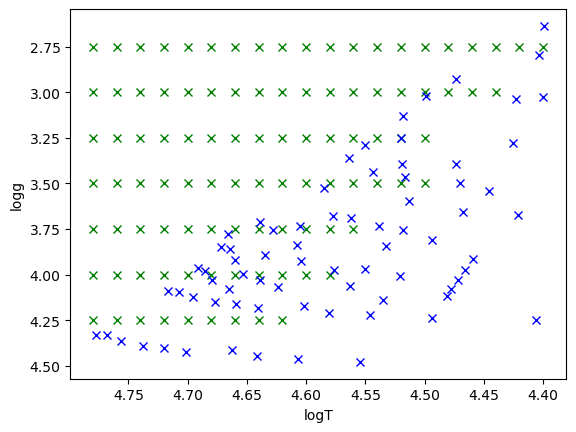

In [89]:
# hack for the super-solar case since the Brown models only go up to solar
if logz_all[zi] > 0:
    logz_brown[-1] = logz_all[zi]

logt_b_grid, logg_b_grid, logz_b_grid = np.meshgrid(logt_brown, logg_brown, logz_brown, indexing='ij')
logt_b_gridcoord, logg_b_gridcoord, logz_b_gridcoord = np.meshgrid(np.arange(len(logt_brown)), np.arange(len(logg_brown)), np.arange(len(logz_brown)), indexing='ij')
b_mask_grid = np.ones(logt_b_grid.shape, dtype=bool)
wh5000 = np.argmin(np.abs(wavelength - 5000.))
for i in range(logt_brown.size):
    for j in range(logg_brown.size):
        for k in range(logz_brown.size):
            if (library_in[wh5000,i,j,k] == 0.):
                b_mask_grid[i,j,k] = False

logt_flat = logt_b_grid[b_mask_grid]
logg_flat = logg_b_grid[b_mask_grid]
logz_flat = logz_b_grid[b_mask_grid]
logt_flat_coord = logt_b_gridcoord[b_mask_grid]
logg_flat_coord = logg_b_gridcoord[b_mask_grid]
logz_flat_coord = logz_b_gridcoord[b_mask_grid]
library_flat = library_in[:,b_mask_grid]

grid_in = list(zip(logts, loggs))
grid_in_b = list(zip(logt_flat, logg_flat, logz_flat))

dlogt_o = 0.02
dlogg_o = 0.25
logt_o = np.arange(dlogt_o*np.round(logts.min()/dlogt_o), dlogt_o*np.round(logts.max()/dlogt_o)+dlogt_o, dlogt_o)
logg_o = np.arange(dlogg_o*np.round(loggs.min()/dlogg_o), dlogg_o*np.round(loggs.max()/dlogg_o)+dlogg_o, dlogg_o)

logt_o_grid, logg_o_grid = np.meshgrid(logt_o, logg_o, indexing='ij')

# remove some parameter space
o_good = np.zeros(logt_o_grid.shape, dtype=bool)
o_good[np.isclose(logt_o_grid, 4.40, rtol=1e-4) & (logg_o_grid < 3.00)] = True
o_good[np.isclose(logt_o_grid, 4.42, rtol=1e-4) & (logg_o_grid < 3.00)] = True
o_good[np.isclose(logt_o_grid, 4.44, rtol=1e-4) & (logg_o_grid < 3.25)] = True
o_good[np.isclose(logt_o_grid, 4.46, rtol=1e-4) & (logg_o_grid < 3.25)] = True
o_good[np.isclose(logt_o_grid, 4.48, rtol=1e-4) & (logg_o_grid < 3.25)] = True
o_good[np.isclose(logt_o_grid, 4.50, rtol=1e-4) & (logg_o_grid < 3.75)] = True
o_good[np.isclose(logt_o_grid, 4.52, rtol=1e-4) & (logg_o_grid < 3.75)] = True
o_good[np.isclose(logt_o_grid, 4.54, rtol=1e-4) & (logg_o_grid < 3.75)] = True
o_good[np.isclose(logt_o_grid, 4.56, rtol=1e-4) & (logg_o_grid < 4.00)] = True
o_good[np.isclose(logt_o_grid, 4.58, rtol=1e-4) & (logg_o_grid < 4.25)] = True
o_good[np.isclose(logt_o_grid, 4.60, rtol=1e-4) & (logg_o_grid < 4.25)] = True
o_good[(logt_o_grid >= 4.61) & (logg_o_grid < 4.50)] = True

logt_o_flat = logt_o_grid[o_good]
logg_o_flat = logg_o_grid[o_good]

grid_out = list(zip(logt_o_flat, logg_o_flat))
grid_out_b = list(zip(logt_o_flat, logg_o_flat, np.ones(len(logt_o_flat))*logz_all[zi]))

logt_o_gridcoord, logg_o_gridcoord = np.meshgrid(np.arange(len(logt_o)), np.arange(len(logg_o)), indexing='ij')
logt_o_flat_gridcoord = logt_o_gridcoord[o_good]
logg_o_flat_gridcoord = logg_o_gridcoord[o_good]

grid_out_coord = list(zip(logt_o_flat_gridcoord, logg_o_flat_gridcoord))

print(grid_in)
print(grid_in_b)
print(grid_out)
print(grid_out_b)
print(grid_out_coord)

# Simple Teff/logg plot showing parameter space coverage
fig, ax = plt.subplots()
for i in range(len(grid_out)):
    ax.plot(grid_out[i][0], grid_out[i][1], 'gx')
for i in range(len(grid_in)):
    ax.plot(grid_in[i][0], grid_in[i][1], 'bx')
# ax.plot([go[0] for go in grid_out], [go[1] for go in grid_out], 'rx')
# ax.plot([gi[0] for gi in grid_in],  [gi[1] for gi in grid_in],  'bx')
# ax.annotate(f'logz = {logz[zi]}', (0.05, 0.95), ha='left', va='top', xycoords=ax.transAxes)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('logT')
ax.set_ylabel('logg')
plt.show()

In [90]:
# do 2D bilinear interpolation over the convex hull that the input covers
wmb_out = np.zeros((len(wavelength), len(logt_o), len(logg_o)))
brn_out = np.zeros((len(wavelength), len(logt_o), len(logg_o)))

for wi in tqdm.trange(len(wavelength)):
    
    bout = interpolate.griddata(grid_in_b, library_flat[wi,:], grid_out_b, method='linear', fill_value=0.)
    for k, gridpoint in enumerate(grid_out_coord):
        brn_out[wi, gridpoint[0], gridpoint[1]] = bout[k]

    if any(wmb[wi,:] > 0.):
        wout = interpolate.griddata(grid_in, wmb[wi,:], grid_out, method='linear', fill_value=0.)
        for k, gridpoint in enumerate(grid_out_coord):
            wmb_out[wi, gridpoint[0], gridpoint[1]] = wout[k]


100%|██████████| 5547/5547 [14:28<00:00,  6.39it/s]


In [91]:
library_out = np.zeros(wmb_out.shape)
wmb_data = np.zeros((len(logt_o), len(logg_o)), dtype=bool)

# Now we need to stitch the N grids together
for k,gridpoint in enumerate(grid_out_coord):
    xi,yi = gridpoint

    wavegood = wmb_out[:,xi,yi] != 0.
    if np.sum(wavegood) == 0:
        continue

    scale = np.nanmedian(brn_out[wavegood,xi,yi] / wmb_out[wavegood,xi,yi])
    library_out[:,xi,yi] = brn_out[:,xi,yi]
    library_out[wavegood,xi,yi] = wmb_out[wavegood,xi,yi]*scale
    wmb_data[xi,yi] = True

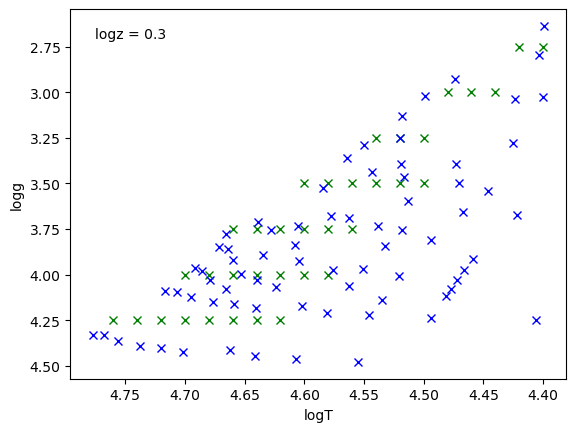

In [92]:
fig, ax = plt.subplots()
for lti in range(len(logt_o)):
    for lgi in range(len(logg_o)):
        if wmb_data[lti,lgi]:
            ax.plot(logt_o[lti], logg_o[lgi], 'gx')
for i in range(len(grid_in)):
    ax.plot(grid_in[i][0], grid_in[i][1], 'bx')
ax.annotate(f'logz = {logz_all[zi]}', (0.05, 0.95), ha='left', va='top', xycoords=ax.transAxes)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('logT')
ax.set_ylabel('logg')
plt.show()

0
25118.864315095823 2.75 0.3


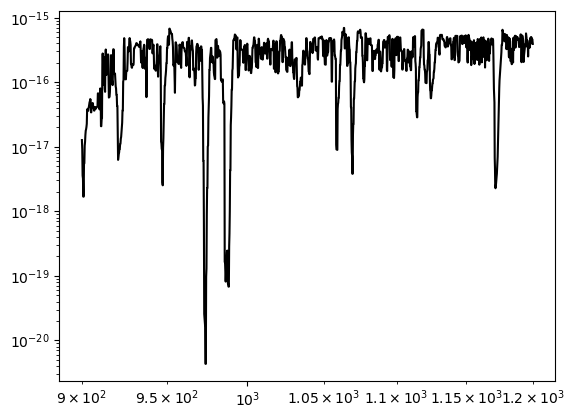

1
26302.679918953814 2.75 0.3


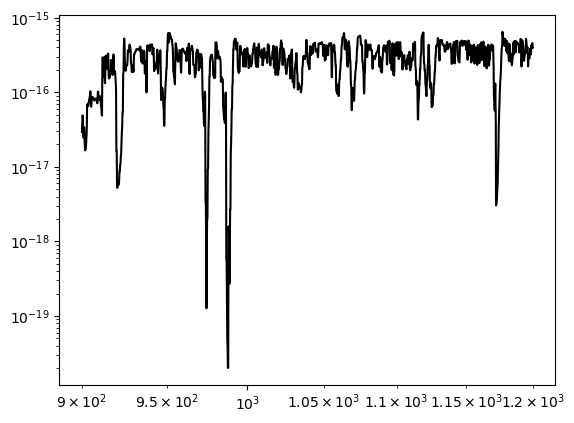

3
27542.28703338163 3.0 0.3


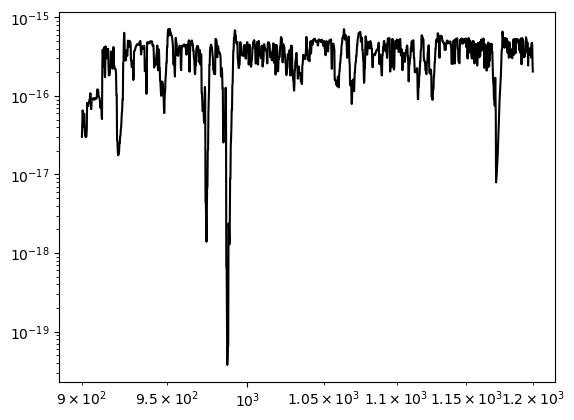

5
28840.315031265996 3.0 0.3


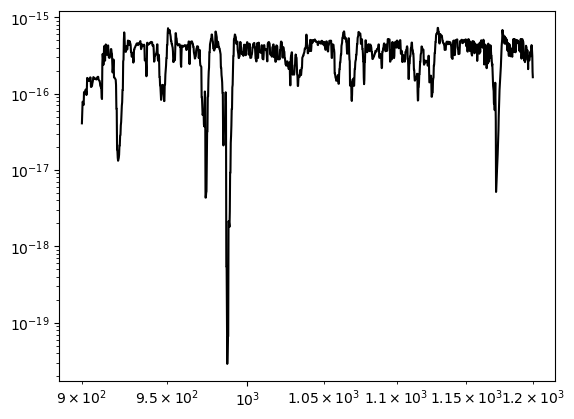

7
30199.517204020067 3.0 0.3


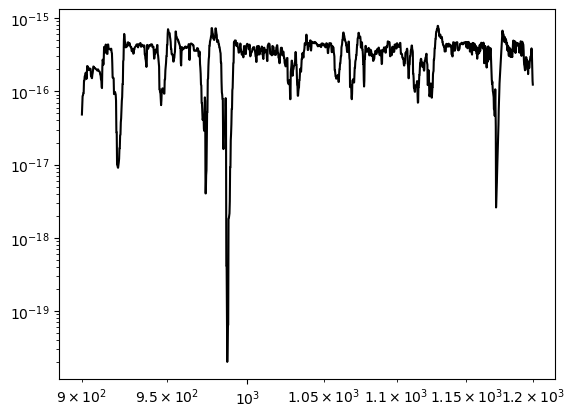

10
31622.776601683665 3.25 0.3


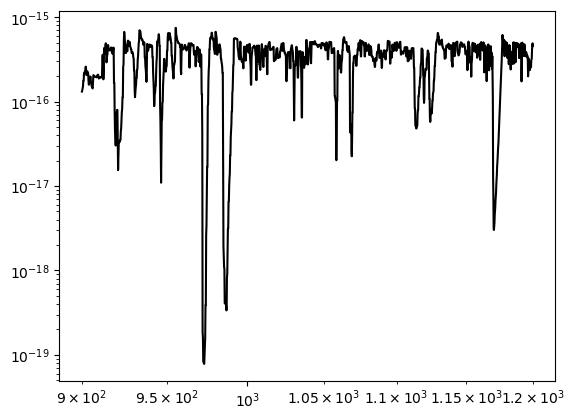

11
31622.776601683665 3.5 0.3


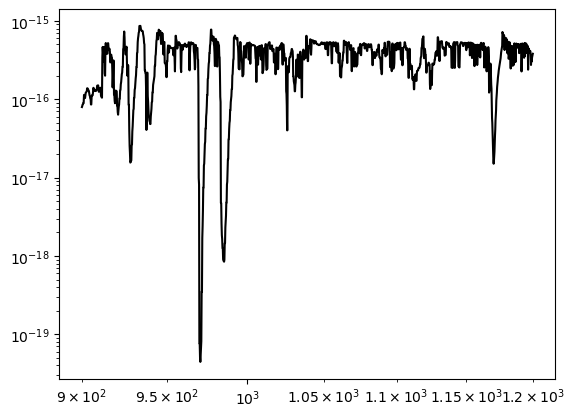

14
33113.112148258944 3.25 0.3


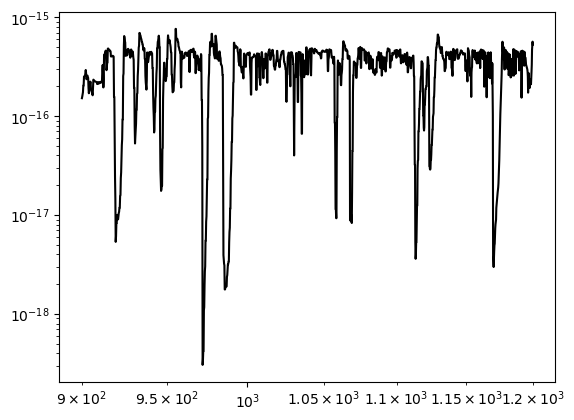

15
33113.112148258944 3.5 0.3


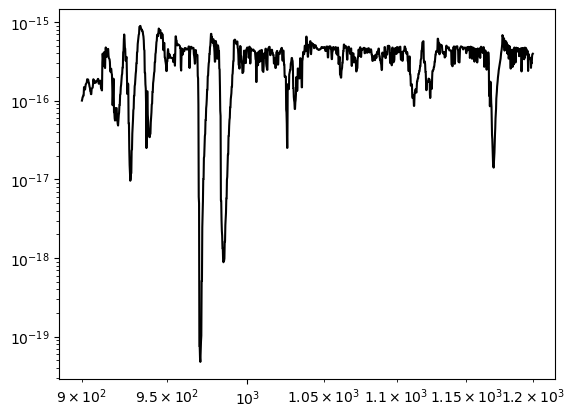

18
34673.685045252954 3.25 0.3


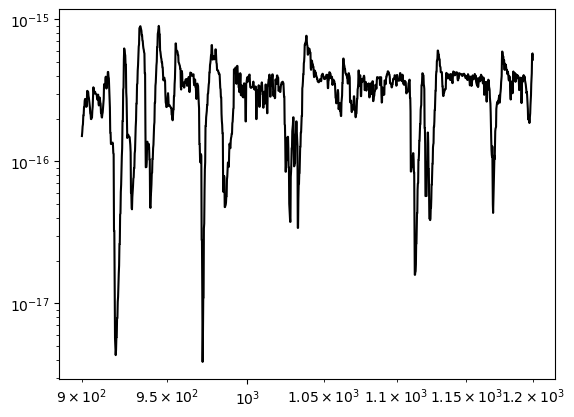

19
34673.685045252954 3.5 0.3


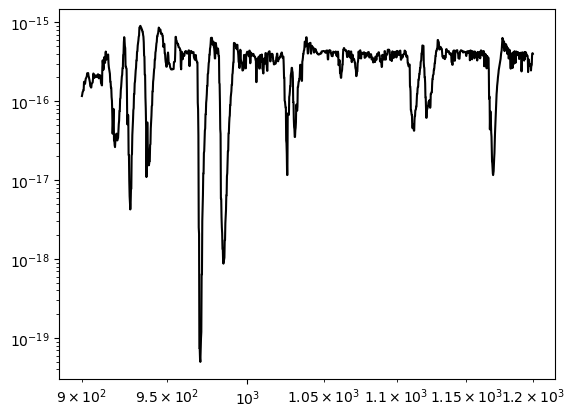

23
36307.805477009875 3.5 0.3


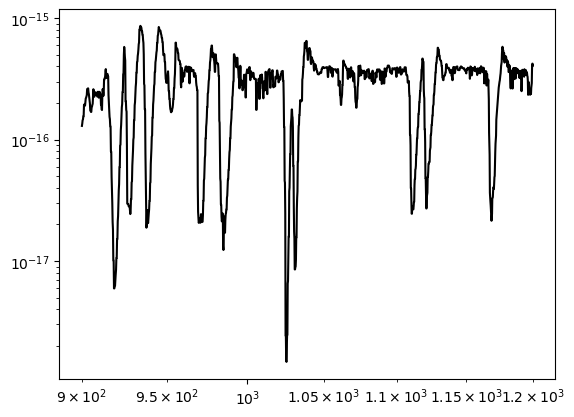

24
36307.805477009875 3.75 0.3


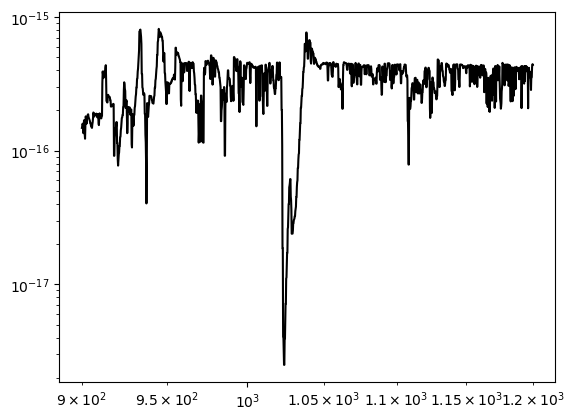

28
38018.939632055815 3.5 0.3


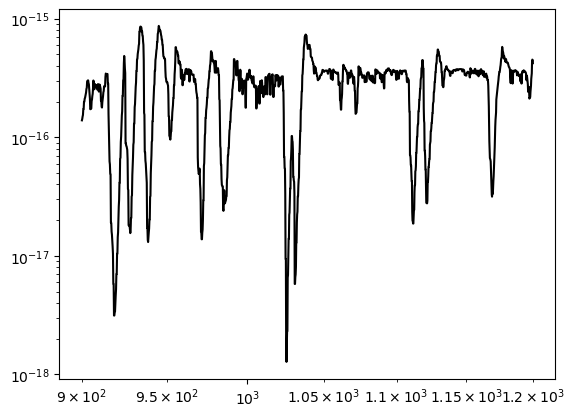

29
38018.939632055815 3.75 0.3


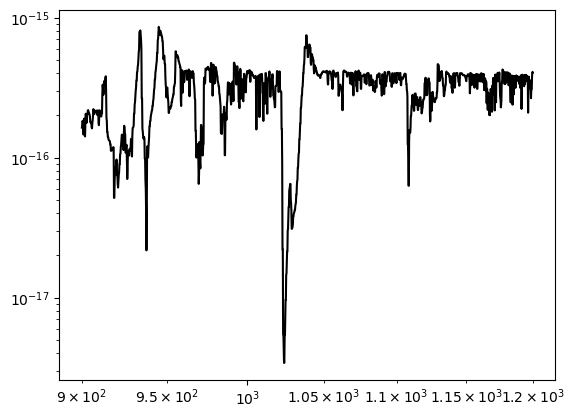

30
38018.939632055815 4.0 0.3


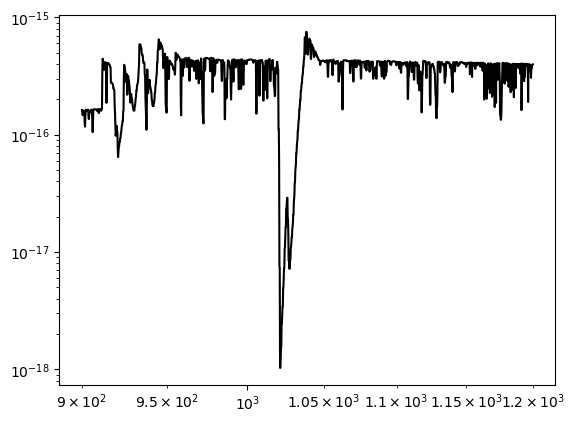

34
39810.71705534936 3.5 0.3


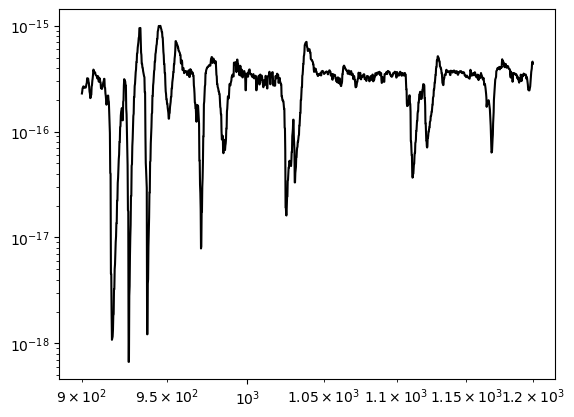

35
39810.71705534936 3.75 0.3


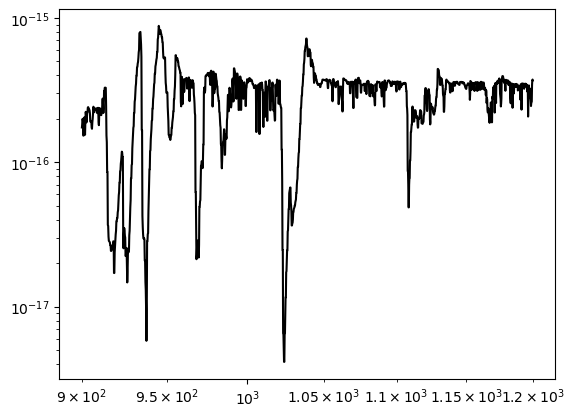

36
39810.71705534936 4.0 0.3


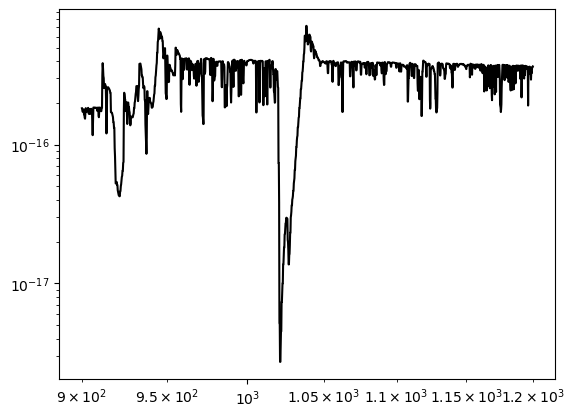

41
41686.93834703312 3.75 0.3


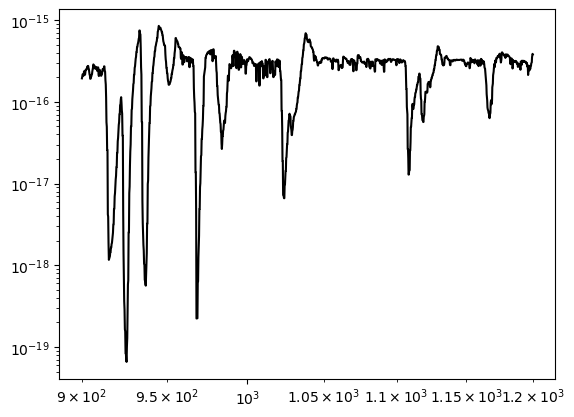

42
41686.93834703312 4.0 0.3


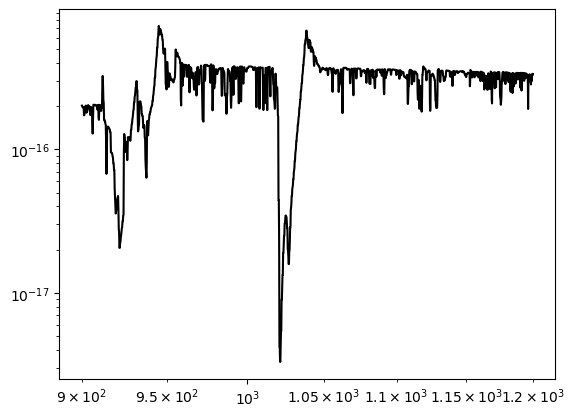

43
41686.93834703312 4.25 0.3


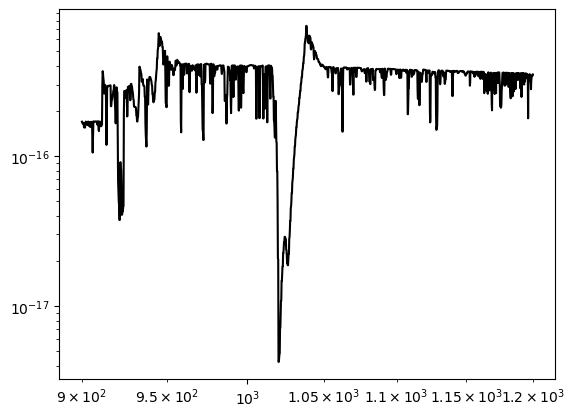

48
43651.58322401612 3.75 0.3


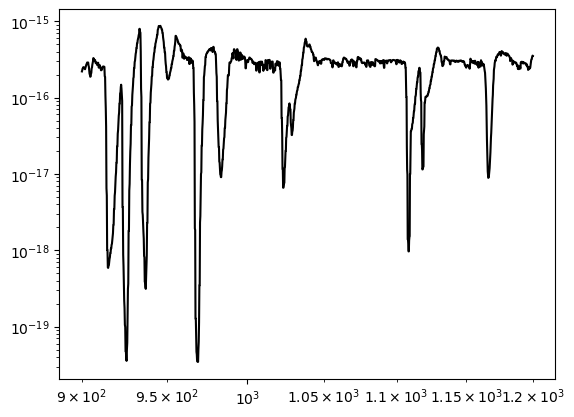

49
43651.58322401612 4.0 0.3


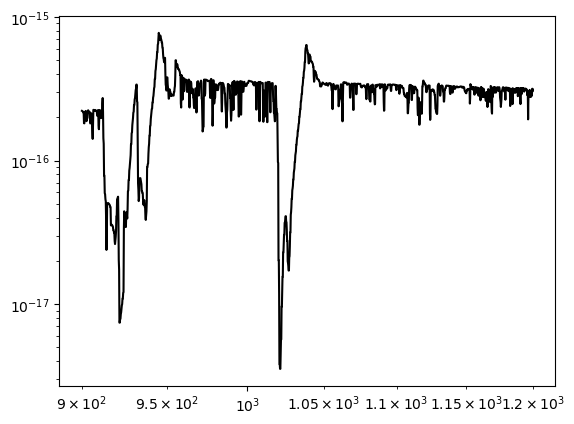

50
43651.58322401612 4.25 0.3


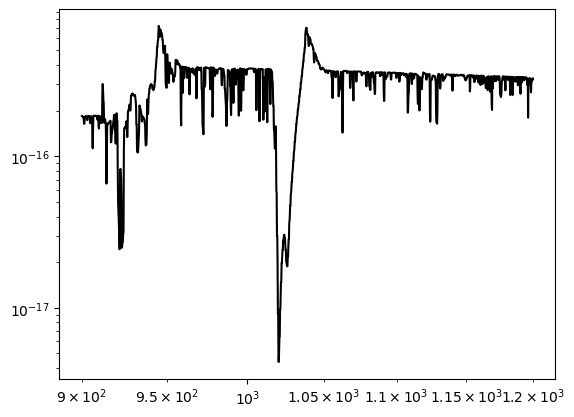

55
45708.818961486955 3.75 0.3


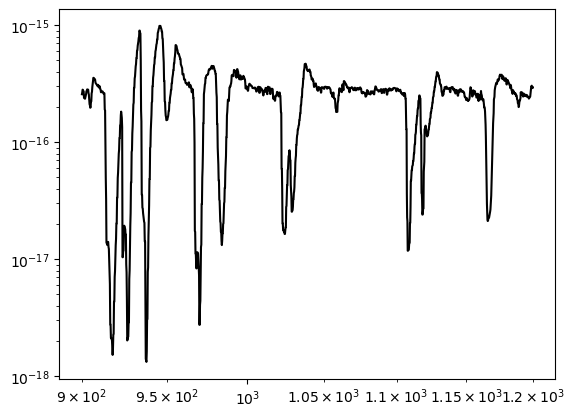

56
45708.818961486955 4.0 0.3


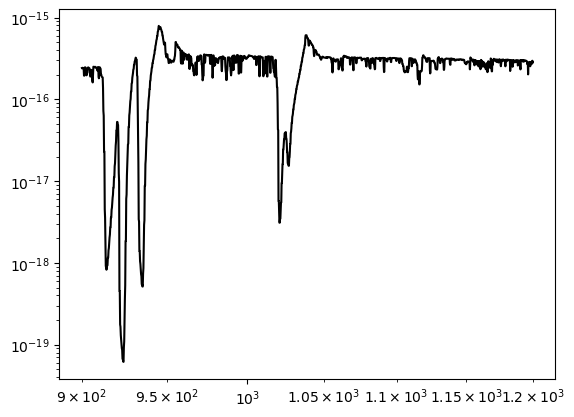

57
45708.818961486955 4.25 0.3


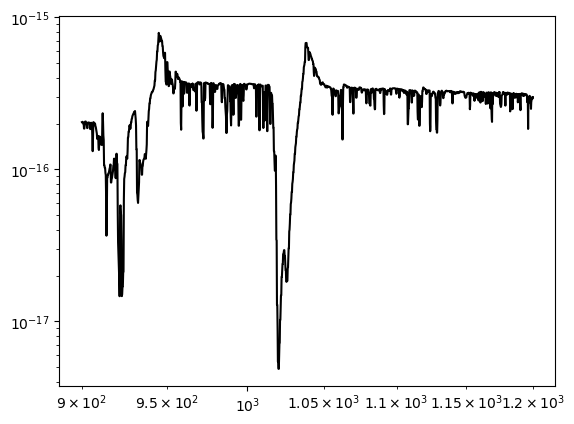

63
47863.00923226322 4.0 0.3


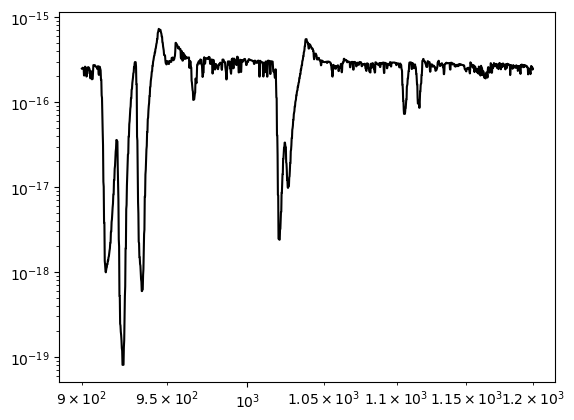

64
47863.00923226322 4.25 0.3


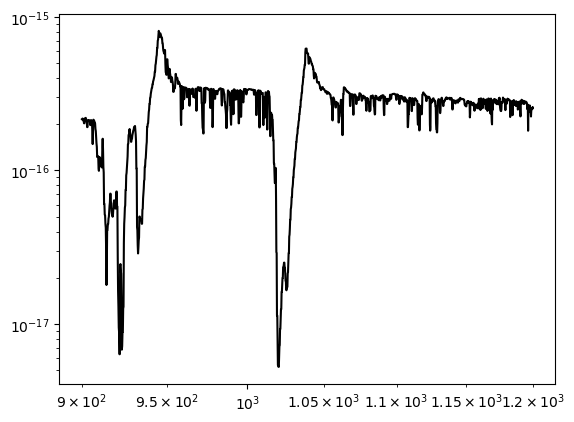

70
50118.72336272653 4.0 0.3


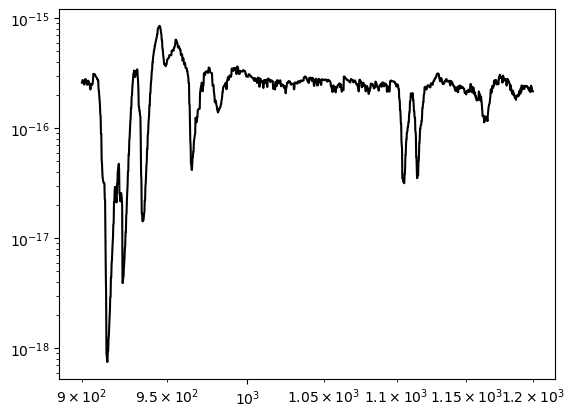

71
50118.72336272653 4.25 0.3


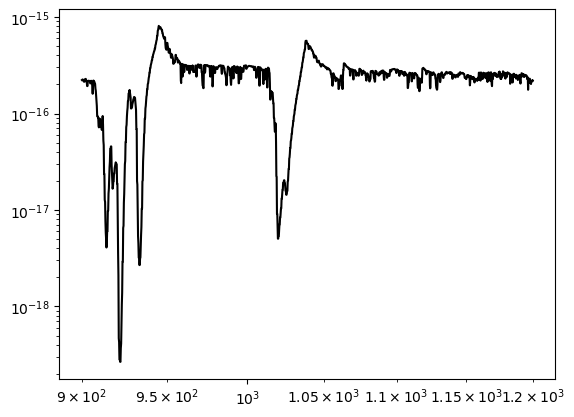

78
52480.74602497648 4.25 0.3


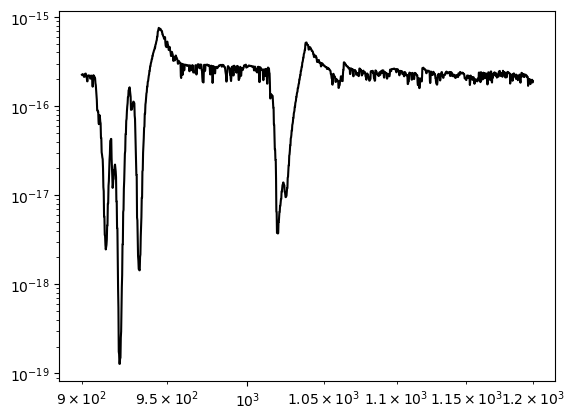

85
54954.08738576158 4.25 0.3


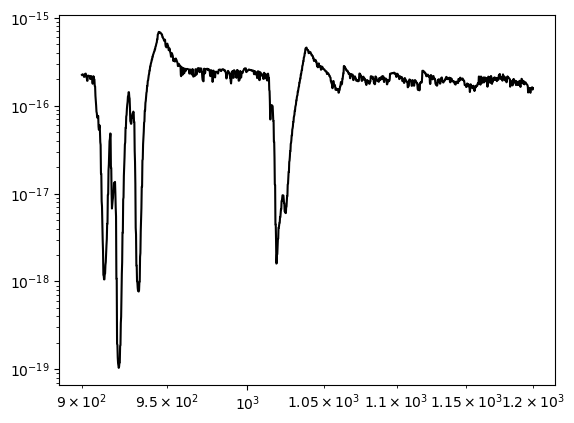

92
57543.99373371472 4.25 0.3


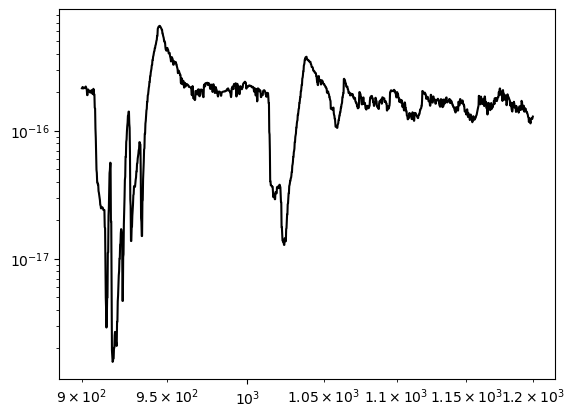

In [93]:
# Preview some resampled spectra
for i in range(len(grid_out)):   
    if any(wmb_out[:,grid_out_coord[i][0],grid_out_coord[i][1]] > 0):
        print(i)
        print(10**grid_out[i][0], grid_out[i][1], logz_all[zi])
        fig, ax = plt.subplots()
        window = (wavelength > 900) & (wavelength < 1200)
        ax.loglog(wavelength[window], library_out[window,grid_out_coord[i][0],grid_out_coord[i][1]], 'k-')
        # ax.set_xlim(1000,1060)
        # ax.set_xlim(900,1200)
        # ax.set_ylim(1e-18, 1e-15)
        plt.show()
        # break

In [94]:
library_out.shape

(5547, 20, 8)

In [95]:
# Save as a text file with the same format as the format 
zsun = 0.0134
z = 10**logz_all[zi] * zsun
# need to flatten the array to 2D matching the shape of the WM-Basic arrays FSPS uses
# (flatten logt and logg axis, should be ordered as [t1_g1 t2_g1 t3_g1 ... t1_g2 t2_g2 t3_g2 ...])
library_outpt = library_out.reshape(library_out.shape[0], len(logt_o)*len(logg_o), order='F')
# append the wavelength column
library_outpt = np.concatenate((wavelength.reshape(len(wavelength), 1), library_outpt), axis=1)

np.savetxt(os.path.join(SPS_HOME, f'SPECTRA/Hot_spectra/Leitherer2010/Leitherer2010z{z:.4f}.spec'), library_outpt, fmt='%.4e', delimiter=' ')

In [96]:
# save other ancillary files
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/Hot_spectra/Leitherer2010/Leitherer2010.teff'), logt_o, fmt='%13.5f')
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/Hot_spectra/Leitherer2010/Leitherer2010.logg'), logg_o, fmt='%13.5f')
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/Hot_spectra/Leitherer2010/Leitherer2010_zlegend.dat'), 10**logz_all*zsun, fmt='%7.4f')